# Antarctic Surface Mass Balance Reconstruction (1801–2025)

Offline ensemble square-root filter (EnSRF) assimilation of 164 ice-core records into a 42-member RACMO2.4p1 (ANT11, 5.5 km) prior, with a Law-of-Total-Variance (LTV) amplitude correction, a generalized Gauss–Markov (GGM) natural-variability null, SAM/temperature attribution, and a mass-budget comparison against ISMIP6 and GRACE.

Regions: AIS (whole grounded ice sheet), WAIS, EAIS, AP (IMBIE basin groups).


## 1 · Setup and data

Imports, file paths, RACMO SMB + T2m fields, grounded-ice / IMBIE basin masks, and the raw RACMO regional SMB series.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
from scipy import stats
from scipy.spatial import cKDTree
from sklearn.linear_model import LinearRegression


In [2]:
data_dir = os.path.expanduser("~/DataFiles")
racmo_smb_file = data_dir + "/smbgl_monthlyS_ANT11_RACMO2.4p1_ERA5_197901_202512.nc"
racmo_t2m_file = data_dir + "/tas_monthlyA_ANT11_RACMO2.4p1_ERA5_197901_202512.nc"
racmo_mask_file = data_dir + "/TotIS_RACMO_ANT27_IMBIE2.nc"
ant11_mask_file = data_dir + "/ANT11_masks.nc"
ant27_ref_file  = data_dir + "/smb_monthlyS_ANT27_ERA5-3H_RACMO2.3p2_197901_202212.nc"
accum_data_file   = data_dir + "/AccumCoresData.csv"
water_data_file   = data_dir + "/WaterCoresData.csv"
accum_coords_file = data_dir + "/AccumCoresCoords.csv"
water_coords_file = data_dir + "/WaterCoresCoords.csv"


In [3]:
smb_ds = xr.open_dataset(racmo_smb_file)
smb_ann = (smb_ds["smbgl"].squeeze("height").groupby("time.year").sum("time").sel(year=slice(1979, 2025)))
t2m_ds = xr.open_dataset(racmo_t2m_file)
t2m_ann = (t2m_ds["tas"].squeeze("height").groupby("time.year").mean("time").sel(year=slice(1979, 2025)))
lat_racmo, lon_racmo = smb_ann["lat"].values, smb_ann["lon"].values
NY, NX = lat_racmo.shape; years_obs = smb_ann["year"].values
print("ANT11 grid:", (NY, NX), " years", int(years_obs.min()), "-", int(years_obs.max()))



ANT11 grid: (591, 726)  years 1979 - 2025


In [4]:
mask_ds = xr.open_dataset(ant11_mask_file)
cell_area_m2 = mask_ds["Area"].values * 1e6
ice_sheet    = mask_ds["Icesheet_Only"].values == 1
def to_xyz(lat, lon):
    la, lo = np.deg2rad(lat), np.deg2rad(lon)
    return np.stack([np.cos(la)*np.cos(lo), np.cos(la)*np.sin(lo), np.sin(la)], -1)
ref27 = xr.open_dataset(ant27_ref_file)["smb"].squeeze("height")
lat27, lon27 = ref27["lat"].values, ref27["lon"].values
gi = xr.open_dataset(racmo_mask_file)["GroundedIce"].values
gi = np.where(np.isfinite(gi), gi, 0).astype(int); _gm = gi > 0
_, _idx = cKDTree(to_xyz(lat27[_gm].ravel(), lon27[_gm].ravel())).query(to_xyz(lat_racmo.ravel(), lon_racmo.ravel()))
basin_mask = np.where(ice_sheet.ravel(), gi[_gm].ravel()[_idx], 0).reshape(NY, NX)
grounded_mask = np.load(os.path.expanduser("~/DataFiles/ANT11_grounded_mask.npy"))
basin_mask = np.where(grounded_mask, basin_mask, 0)      # drop floating ice shelves -> grounded ice only

basin_flat = basin_mask.reshape(-1); valid_cells = basin_flat > 0
basin_ids  = basin_flat[valid_cells].astype(int); basin_ids_unique = np.unique(basin_ids)
region_names = ["AIS", "WAIS", "EAIS", "AP"]
print("grounded cells:", int(valid_cells.sum()))


grounded cells: 101022


In [5]:
def basin_sums_Gt(field3d, years):
    mass = field3d * cell_area_m2
    df = pd.DataFrame(index=list(np.asarray(years)), columns=basin_ids_unique, dtype=float)
    for t, yr in enumerate(np.asarray(years)):
        flat = mass[t].reshape(-1)[valid_cells]
        s = pd.DataFrame({"basin": basin_ids, "m": flat}).groupby("basin")["m"].sum() / 1e12
        df.loc[yr, s.index] = s.values
    return df


In [6]:
smb_basin_obs = basin_sums_Gt(smb_ann.values, years_obs)
ais_rac  = smb_basin_obs.sum(axis=1).astype(float)
wais_rac = smb_basin_obs[[3,7,8,9,10]].sum(axis=1).astype(float)
eais_rac = smb_basin_obs[[1,2,11,12,13,14,15,16,17,18]].sum(axis=1).astype(float)
ap_rac   = smb_basin_obs[[4,5,6]].sum(axis=1).astype(float)
raw_series = {"AIS": ais_rac, "WAIS": wais_rac, "EAIS": eais_rac, "AP": ap_rac}


## 2 · Ice cores and proxy system models

Load the accumulation and water-isotope records, build the per-core PSMs (identity onto RACMO SMB for accumulation; T2m regression for water isotopes) and their observation-error variances `R`. Figures: proxy network map and temporal coverage.

In [7]:
accum_data_raw = pd.read_csv(accum_data_file, header=None)
water_data_raw = pd.read_csv(water_data_file, header=None)
def extract_cores(raw_df, yr_min, yr_max, transpose=True):
    years_col = raw_df.iloc[2:, 0].astype(int)
    m = (years_col >= yr_min) & (years_col <= yr_max)
    arr = raw_df.iloc[2:, 1:][m].to_numpy()[::-1].astype(float)
    return arr.T if transpose else arr
N_CAL = 42; CAL_YEARS = slice(1979, 2020); recon_years = np.arange(1801, 2001)
accum_cores_cal  = extract_cores(accum_data_raw, 1979, 2020)
water_cores_cal  = extract_cores(water_data_raw, 1979, 2020)
accum_cores_full = extract_cores(accum_data_raw, 1801, 2000, transpose=False)
water_cores_full = extract_cores(water_data_raw, 1801, 2000, transpose=False)
accum_coords = pd.read_csv(accum_coords_file, header=None)
water_coords = pd.read_csv(water_coords_file, header=None)
core_lats  = accum_coords.iloc[:, 2].values; core_lons  = (accum_coords.iloc[:, 3].values + 360) % 360
water_lats = water_coords.iloc[:, 2].values; water_lons = (water_coords.iloc[:, 3].values + 360) % 360
print("accum cores:", accum_cores_full.shape[1], " water cores:", water_cores_full.shape[1])


accum cores: 84  water cores: 80


In [8]:
def nearest_ij(lat2d, lon2d, tlat, tlon):
    lon360 = (lon2d + 360) % 360
    d2 = (lat2d - tlat)**2 + (lon360 - (tlon + 360) % 360)**2
    return np.unravel_index(np.argmin(d2), d2.shape)
smb_cal = smb_ann.sel(year=CAL_YEARS).values; t2m_cal = t2m_ann.sel(year=CAL_YEARS).values
accum_pts = np.zeros((84, N_CAL)); R_accum = np.zeros(84)
for i in range(84):
    j, k = nearest_ij(lat_racmo, lon_racmo, core_lats[i], core_lons[i])
    smb_pt = smb_cal[:, j, k]; obs = accum_cores_cal[i, :]; accum_pts[i, :] = smb_pt
    v = np.isfinite(obs) & np.isfinite(smb_pt)
    reg = LinearRegression().fit(smb_pt[v].reshape(-1,1), obs[v].reshape(-1,1))
    R_accum[i] = np.var(obs[v].reshape(-1,1) - reg.predict(smb_pt[v].reshape(-1,1)), ddof=1)
_valid = np.isfinite(accum_cores_cal) & np.isfinite(accum_pts)
_off = (np.nanmean(np.where(_valid, accum_cores_cal, np.nan), axis=1)
        - np.nanmean(np.where(_valid, accum_pts, np.nan), axis=1))
y_e_accum = accum_pts + _off[:, None]
y_e_water = np.zeros((80, N_CAL)); R_water = np.zeros(80)
for i in range(80):
    j, k = nearest_ij(lat_racmo, lon_racmo, water_lats[i], water_lons[i])
    t_pt = t2m_cal[:, j, k]; obs = water_cores_cal[i, :]
    v = np.isfinite(obs) & np.isfinite(t_pt)
    reg = LinearRegression().fit(t_pt[v].reshape(-1,1), obs[v].reshape(-1,1))
    y_e_water[i, :] = t_pt * reg.coef_[0][0] + reg.intercept_[0]
    R_water[i] = np.var(obs[v].reshape(-1,1) - reg.predict(t_pt[v].reshape(-1,1)), ddof=1)
y_e_smb = np.vstack([y_e_accum, y_e_water]); R_smb_diag = np.concatenate([R_accum, R_water])
proxy_smb = np.hstack([accum_cores_full, water_cores_full])
print("PSMs ready:", y_e_smb.shape)


PSMs ready: (164, 42)


/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


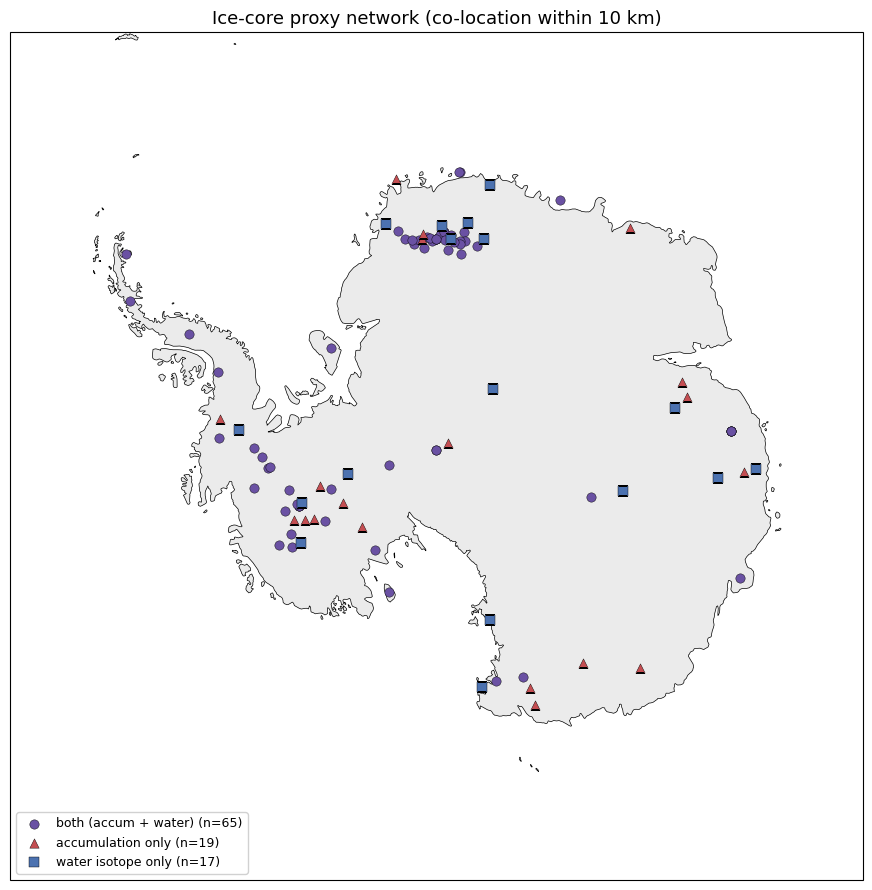

In [9]:
_xyz = lambda lat, lon: np.stack([np.cos(np.deg2rad(lat))*np.cos(np.deg2rad(lon)),
                                  np.cos(np.deg2rad(lat))*np.sin(np.deg2rad(lon)), np.sin(np.deg2rad(lat))], -1)
chord_km = lambda d: 2*np.arcsin(np.clip(d/2, 0, 1))*6371.0
MATCH_KM = 10.0
acc_xyz, wat_xyz = _xyz(core_lats, core_lons), _xyz(water_lats, water_lons)
acc_has_water = chord_km(cKDTree(wat_xyz).query(acc_xyz)[0]) < MATCH_KM
wat_has_acc   = chord_km(cKDTree(acc_xyz).query(wat_xyz)[0]) < MATCH_KM
fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={"projection": ccrs.SouthPolarStereo()})
ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=0); ax.add_feature(cfeature.LAND, facecolor="0.92", zorder=1)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=2)
for lon, lat, c, mk, lbl in [
        (core_lons[acc_has_water], core_lats[acc_has_water], "#6A51A3", "o", "both (accum + water)"),
        (core_lons[~acc_has_water], core_lats[~acc_has_water], "#C44E52", "^", "accumulation only"),
        (water_lons[~wat_has_acc], water_lats[~wat_has_acc], "#4C72B0", "s", "water isotope only")]:
    ax.scatter(lon, lat, s=45, c=c, marker=mk, edgecolor="k", linewidth=0.3,
               transform=ccrs.PlateCarree(), zorder=3, label=f"{lbl} (n={len(lon)})")
ax.legend(loc="lower left", fontsize=9, framealpha=0.9)
ax.set_title(f"Ice-core proxy network (co-location within {MATCH_KM:.0f} km)", fontsize=13)
plt.tight_layout(); plt.show()


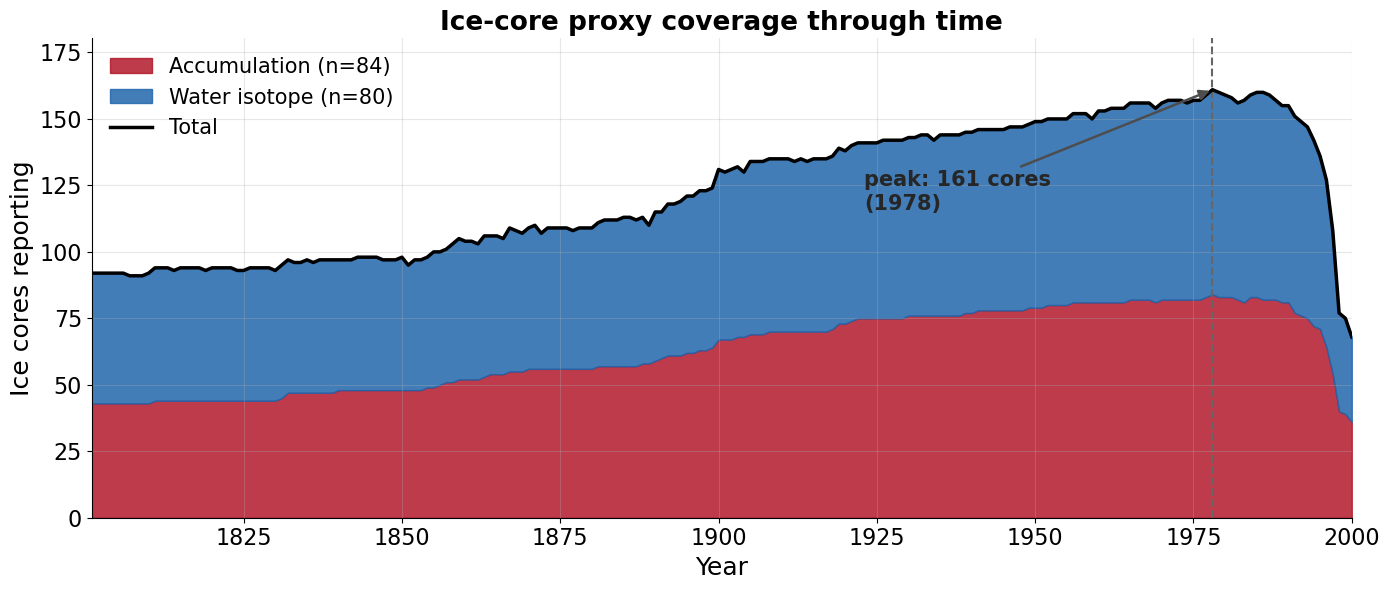

Maximum coverage:
  Total            max = 161 cores   in 1978
  Accumulation     max =  84 cores   in 1978
  Water isotope    max =  78 cores   in 1986

  At the total peak (1978): 84 accumulation + 77 water-isotope cores


In [10]:
# ===== Ice-core coverage over time: accumulation vs water-isotope =====
n_accum = np.isfinite(accum_cores_full).sum(axis=1)   # cores reporting each year (200,)
n_water = np.isfinite(water_cores_full).sum(axis=1)
n_total = n_accum + n_water

fig, ax = plt.subplots(figsize=(14, 6))
ax.fill_between(recon_years, 0, n_accum, color="#B2182B", alpha=0.85, label=f"Accumulation (n={accum_cores_full.shape[1]})")
ax.fill_between(recon_years, n_accum, n_total, color="#2166AC", alpha=0.85, label=f"Water isotope (n={water_cores_full.shape[1]})")
ax.plot(recon_years, n_total, color="black", lw=2.5, label="Total")

ymax = int(n_total.max()); yr_max = int(recon_years[np.argmax(n_total)])
ax.axvline(yr_max, color="0.4", lw=1.5, ls="--", zorder=1)
ax.annotate(f"peak: {ymax} cores\n({yr_max})", xy=(yr_max, ymax), xytext=(yr_max-55, ymax*0.72),
            fontsize=15, fontweight="bold", color="0.15",
            arrowprops=dict(arrowstyle="-|>", color="0.3", lw=1.8))

ax.set_xlim(1801, 2000); ax.set_ylim(0, ymax*1.12)
ax.set_xlabel("Year", fontsize=18); ax.set_ylabel("Ice cores reporting", fontsize=18)
ax.tick_params(labelsize=16); ax.grid(alpha=0.3)
ax.legend(fontsize=15, loc="upper left", frameon=False)
for sp in ("top", "right"): ax.spines[sp].set_visible(False)
ax.set_title("Ice-core proxy coverage through time", fontsize=19, fontweight="bold")
plt.tight_layout(); plt.show()

# --- maximum-coverage report ---
def peak(counts, label):
    m = counts.max(); yrs = recon_years[counts == m]
    span = f"{yrs.min()}" if len(yrs) == 1 else f"{yrs.min()}–{yrs.max()} ({len(yrs)} yr)"
    print(f"  {label:<16} max = {int(m):3d} cores   in {span}")
print("Maximum coverage:")
peak(n_total, "Total")
peak(n_accum, "Accumulation")
peak(n_water, "Water isotope")
print(f"\n  At the total peak ({yr_max}): {int(n_accum[np.argmax(n_total)])} accumulation "
      f"+ {int(n_water[np.argmax(n_total)])} water-isotope cores")


## 3 · Data assimilation — offline EnSRF

Ensemble square-root filter driver (no localization) and the run producing the raw 42-member posterior reconstruction.

In [11]:
def run_ensrf_spatial_unc(prior_cells, y_e, R_diag_vec, proxy_data_full, n_proxy, integ):
    Ns = prior_cells.shape[1]
    post_mean = np.zeros((200, Ns), np.float32); post_std = np.zeros((200, Ns), np.float32)
    reg_ens = np.zeros((200, N_CAL, integ.shape[0]))
    for i in range(200):
        X_mean = prior_cells.mean(axis=0); X_dev = prior_cells - X_mean
        for j in range(n_proxy):
            if np.isnan(proxy_data_full[i, j]): continue
            y_mean = y_e[j, :].mean(); y_var = np.var(y_e[j, :], ddof=1)
            if not np.isfinite(y_mean) or y_var == 0: continue
            y_dev = y_e[j, :] - y_mean
            K = ((X_dev.T @ y_dev) / (N_CAL - 1)) / (y_var + R_diag_vec[j])
            X_mean = X_mean + K * (proxy_data_full[i, j] - y_mean)
            alpha = 1.0 / (1.0 + np.sqrt(R_diag_vec[j] / (y_var + R_diag_vec[j])))
            X_dev = X_dev - alpha * np.outer(y_dev, K)
        post_mean[i] = X_mean; post_std[i] = X_dev.std(axis=0, ddof=1)
        reg_ens[i] = (integ @ (X_mean[None, :] + X_dev).T).T
    return post_mean, post_std, reg_ens


In [12]:
_va = cell_area_m2.reshape(-1)[valid_cells]
_regions = {"AIS": basin_ids > 0, "WAIS": np.isin(basin_ids,[3,7,8,9,10]),
            "EAIS": np.isin(basin_ids,[1,2,11,12,13,14,15,16,17,18]), "AP": np.isin(basin_ids,[4,5,6])}
A_smb   = np.vstack([np.where(_regions[r], _va, 0) / 1e12 for r in region_names])
A_basin = np.vstack([np.where(basin_ids == b, _va, 0) / 1e12 for b in basin_ids_unique])
A_all   = np.vstack([A_smb, A_basin])

smb_cells = smb_ann.sel(year=CAL_YEARS).values.reshape(N_CAL, -1)[:, valid_cells].astype(np.float32)
print("Running SMB EnSRF (%d grounded cells) ..." % smb_cells.shape[1])
smb_post_v, smb_std_v, reg_ens_all = run_ensrf_spatial_unc(smb_cells, y_e_smb, R_smb_diag, proxy_smb, 164, A_all)

smb_reg_ens_raw   = reg_ens_all[:, :, :4]
smb_basin_ens_raw = reg_ens_all[:, :, 4:]
racmo_smb_recon_raw = np.full((200, NY*NX), np.nan, np.float32)
racmo_smb_recon_raw[:, valid_cells] = smb_post_v
racmo_smb_recon_raw = racmo_smb_recon_raw.reshape(200, NY, NX)
smb_reg_mean_raw = smb_reg_ens_raw.mean(1); smb_reg_std_raw = smb_reg_ens_raw.std(1, ddof=1)
print("Raw reconstruction ready.")



Running SMB EnSRF (101022 grounded cells) ...
Raw reconstruction ready.


## 4 · Variance correction (LTV)

Law-of-Total-Variance amplitude correction applied to the 1801–1900 baseline window (restores the conditional variance the posterior mean discards). Produces the working series `recon_series`, `smb_reg_ens`, `racmo_smb_recon`. Validation: raw vs corrected series and rolling σ against raw RACMO.

In [13]:
W, FMAX, TAPER_YRS = 31, 5.0, 0        # TAPER_YRS>0 ramps the factor back to 1 over N years after the split
SPLIT_YEAR = 1956                      # <-- tweakable: correction applied THROUGH this year (inclusive)
BASE_END   = 1900                      # baseline + GGM window end — held FIXED at 1900

i_split = int(np.clip(SPLIT_YEAR - 1801 + 1, 0, 200))   # first uncorrected index
i_base  = BASE_END - 1801 + 1                            # = 100, fixed

_r = lambda x: pd.Series(np.asarray(x, float)).rolling(W, center=True, min_periods=max(4, W//2))
roll_mean = lambda x: _r(x).mean().values
roll_var  = lambda x: _r(x).var(ddof=1).values
dvar = lambda x: np.var(np.asarray(x,float)-np.polyval(np.polyfit(np.arange(len(x)),np.asarray(x,float),1),
                                                        np.arange(len(x))), ddof=1)

# --- LTV amplitude per region over the FIXED 1801-BASE_END window (feeds the null) ---
reg_var_raw = smb_reg_ens_raw.var(1, ddof=1)
sig_total_ltv = {}
for k, r in enumerate(region_names):
    v_mean = dvar(smb_reg_mean_raw[0:i_base, k]); v_post = reg_var_raw[0:i_base, k].mean()
    sig_total_ltv[r] = np.sqrt(v_mean + v_post)
    print(f"{r}: sigma_mean {np.sqrt(v_mean):6.1f}   LTV total {sig_total_ltv[r]:6.1f}   "
          f"x{sig_total_ltv[r]/np.sqrt(v_mean):.2f}")

# --- per-basin time-varying factor, applied only through SPLIT_YEAR ---
mean_b = smb_basin_ens_raw.mean(1); var_b = smb_basin_ens_raw.var(1, ddof=1)
f_b = np.ones_like(mean_b)
for b in range(mean_b.shape[1]):
    v_mean, v_post = roll_var(mean_b[:, b]), roll_mean(var_b[:, b])
    f = np.sqrt((v_mean + v_post) / np.maximum(v_mean, 1e-12))
    f_b[:, b] = np.clip(pd.Series(f).ffill().bfill().values, 1.0, FMAX)

f_use = f_b.copy()
f_use[i_split:, :] = 1.0                                   # uncorrected from SPLIT_YEAR+1 onward
if TAPER_YRS > 0:                                          # optional smooth hand-off at the split
    f_edge = f_b[max(i_split-1, 0), :]
    for j in range(TAPER_YRS):
        i = i_split + j
        if i < f_use.shape[0]:
            f_use[i, :] = 1.0 + (f_edge - 1.0) * (1.0 - (j+1)/TAPER_YRS)
print(f"split at {SPLIT_YEAR}: factor there = {f_b[max(i_split-1,0)].mean():.2f}  "
      f"(set TAPER_YRS>0 to smooth the hand-off)")

# --- build the working series: corrected mean, spread preserved; baseline fixed to 1801-BASE_END ---
base_b   = mean_b[0:i_base].mean(0)
mean_cor = base_b + (mean_b - base_b) * f_use
smb_basin_ens = mean_cor[:, None, :] + (smb_basin_ens_raw - mean_b[:, None, :])
bcol = {b: i for i, b in enumerate(basin_ids_unique)}
reg_cols = {"AIS":  [bcol[b] for b in basin_ids_unique],
            "WAIS": [bcol[b] for b in [3,7,8,9,10] if b in bcol],
            "EAIS": [bcol[b] for b in [1,2,11,12,13,14,15,16,17,18] if b in bcol],
            "AP":   [bcol[b] for b in [4,5,6] if b in bcol]}
smb_reg_ens  = np.stack([smb_basin_ens[:, :, reg_cols[r]].sum(2) for r in region_names], axis=2)
smb_reg_mean = smb_reg_ens.mean(1); smb_reg_std = smb_reg_ens.std(1, ddof=1)
ais_rac_recon, wais_rac_recon, eais_rac_recon, ap_rac_recon = (smb_reg_mean[:, k] for k in range(4))
ais_rac_std,  wais_rac_std,  eais_rac_std,  ap_rac_std      = (smb_reg_std[:, k]  for k in range(4))
smb_std_by_region = {"AIS": ais_rac_std, "WAIS": wais_rac_std, "EAIS": eais_rac_std, "AP": ap_rac_std}
recon_series = {"AIS": ais_rac_recon, "WAIS": wais_rac_recon, "EAIS": eais_rac_recon, "AP": ap_rac_recon}

bcell = np.full((NY, NX), -1, int)
for i, b in enumerate(basin_ids_unique): bcell[basin_mask == b] = i
valid2d = bcell >= 0
cellmean = np.nanmean(racmo_smb_recon_raw[:i_base], axis=0)
fcell = f_use[:, np.where(valid2d, bcell, 0)]; fcell[:, ~valid2d] = 1.0
racmo_smb_recon = cellmean[None] + (racmo_smb_recon_raw - cellmean[None]) * fcell
smb_basin_recon = basin_sums_Gt(racmo_smb_recon, recon_years)
print(f"Working series: LTV-corrected 1801-{SPLIT_YEAR}, raw {SPLIT_YEAR+1}-2000.")






AIS: sigma_mean   87.1   LTV total  108.0   x1.24
WAIS: sigma_mean   82.7   LTV total   85.7   x1.04
EAIS: sigma_mean   69.2   LTV total   90.1   x1.30
AP: sigma_mean   30.9   LTV total   36.4   x1.18
split at 1956: factor there = 1.19  (set TAPER_YRS>0 to smooth the hand-off)


/var/folders/4d/5th1wr_s21g614c74mcbh9kc0000gn/T/ipykernel_45822/3291816055.py:61: RuntimeWarning: Mean of empty slice
  cellmean = np.nanmean(racmo_smb_recon_raw[:i_base], axis=0)


Working series: LTV-corrected 1801-1956, raw 1957-2000.


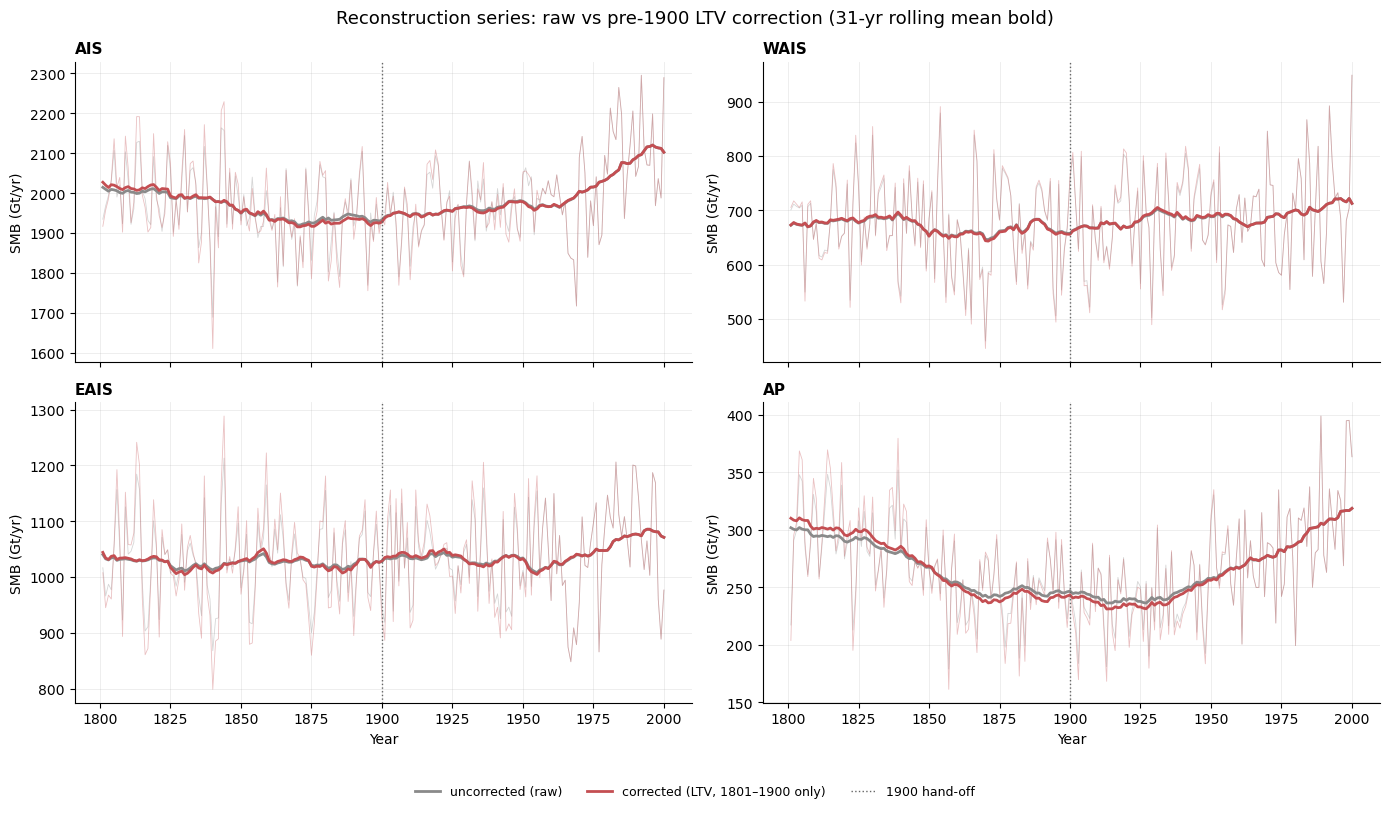

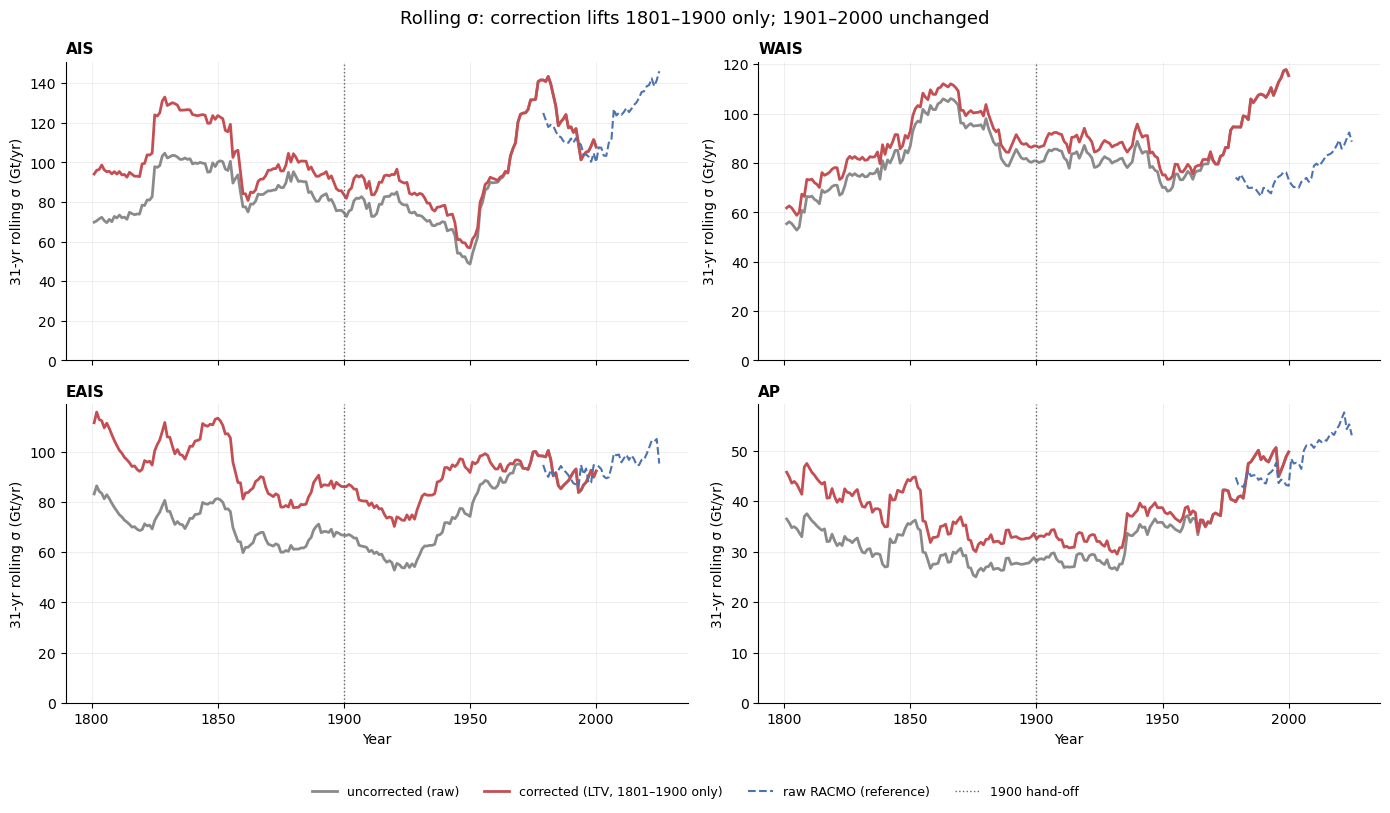

In [14]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.lines import Line2D

Wr = 31
_rr = lambda x: pd.Series(np.asarray(x, float)).rolling(Wr, center=True, min_periods=max(4, Wr//2))
r_mean = lambda x: _rr(x).mean().values
r_std  = lambda x: _rr(x).std(ddof=1).values
years_r = np.arange(1801, 1801 + smb_reg_mean.shape[0])
C_RAW, C_COR, C_REF = "#8a8a8a", "#C44E52", "#4C72B0"

# --- Figure 1: series (annual faint, 31-yr rolling mean bold) ---
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
for ax, (k, r) in zip(axes.ravel(), enumerate(region_names)):
    ax.plot(years_r, smb_reg_mean_raw[:, k], color=C_RAW, lw=0.6, alpha=0.35)
    ax.plot(years_r, smb_reg_mean[:, k],     color=C_COR, lw=0.6, alpha=0.35)
    ax.plot(years_r, r_mean(smb_reg_mean_raw[:, k]), color=C_RAW, lw=2)
    ax.plot(years_r, r_mean(smb_reg_mean[:, k]),     color=C_COR, lw=2)
    ax.axvline(1900, color="0.4", lw=1.0, ls=":")
    ax.set_title(r, fontsize=11, fontweight="bold", loc="left")
    ax.set_ylabel("SMB (Gt/yr)"); ax.grid(alpha=0.25, lw=0.6)
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)
for ax in axes[-1, :]: ax.set_xlabel("Year")
fig.legend(handles=[Line2D([0],[0], color=C_RAW, lw=2, label="uncorrected (raw)"),
                    Line2D([0],[0], color=C_COR, lw=2, label="corrected (LTV, 1801–1900 only)"),
                    Line2D([0],[0], color="0.4", lw=1.0, ls=":", label="1900 hand-off")],
           loc="lower center", ncol=3, frameon=False, fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle(f"Reconstruction series: raw vs pre-1900 LTV correction ({Wr}-yr rolling mean bold)", fontsize=13)
fig.tight_layout(rect=[0, 0.04, 1, 1]); plt.show()

# --- Figure 2: rolling standard deviation, with the raw-RACMO reference ---
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
for ax, (k, r) in zip(axes.ravel(), enumerate(region_names)):
    ax.plot(years_r, r_std(smb_reg_mean_raw[:, k]), color=C_RAW, lw=2)
    ax.plot(years_r, r_std(smb_reg_mean[:, k]),     color=C_COR, lw=2)
    ry = raw_series[r].index.values
    ax.plot(ry, _rr(raw_series[r].values).std(ddof=1).values, color=C_REF, lw=1.5, ls="--")
    ax.axvline(1900, color="0.4", lw=1.0, ls=":")
    ax.set_title(r, fontsize=11, fontweight="bold", loc="left")
    ax.set_ylabel(f"{Wr}-yr rolling σ (Gt/yr)"); ax.set_ylim(bottom=0)
    ax.grid(alpha=0.25, lw=0.6)
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)
for ax in axes[-1, :]: ax.set_xlabel("Year")
fig.legend(handles=[Line2D([0],[0], color=C_RAW, lw=2, label="uncorrected (raw)"),
                    Line2D([0],[0], color=C_COR, lw=2, label="corrected (LTV, 1801–1900 only)"),
                    Line2D([0],[0], color=C_REF, lw=1.5, ls="--", label="raw RACMO (reference)"),
                    Line2D([0],[0], color="0.4", lw=1.0, ls=":", label="1900 hand-off")],
           loc="lower center", ncol=4, frameon=False, fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Rolling σ: correction lifts 1801–1900 only; 1901–2000 unchanged", fontsize=13)
fig.tight_layout(rect=[0, 0.04, 1, 1]); plt.show()


## 5 · Reconstructed SMB — series and trends

AIS SMB time series with spatial-trend maps, and the regional boxplots with 25-year sea-level-mitigation checkpoints (four baselines).

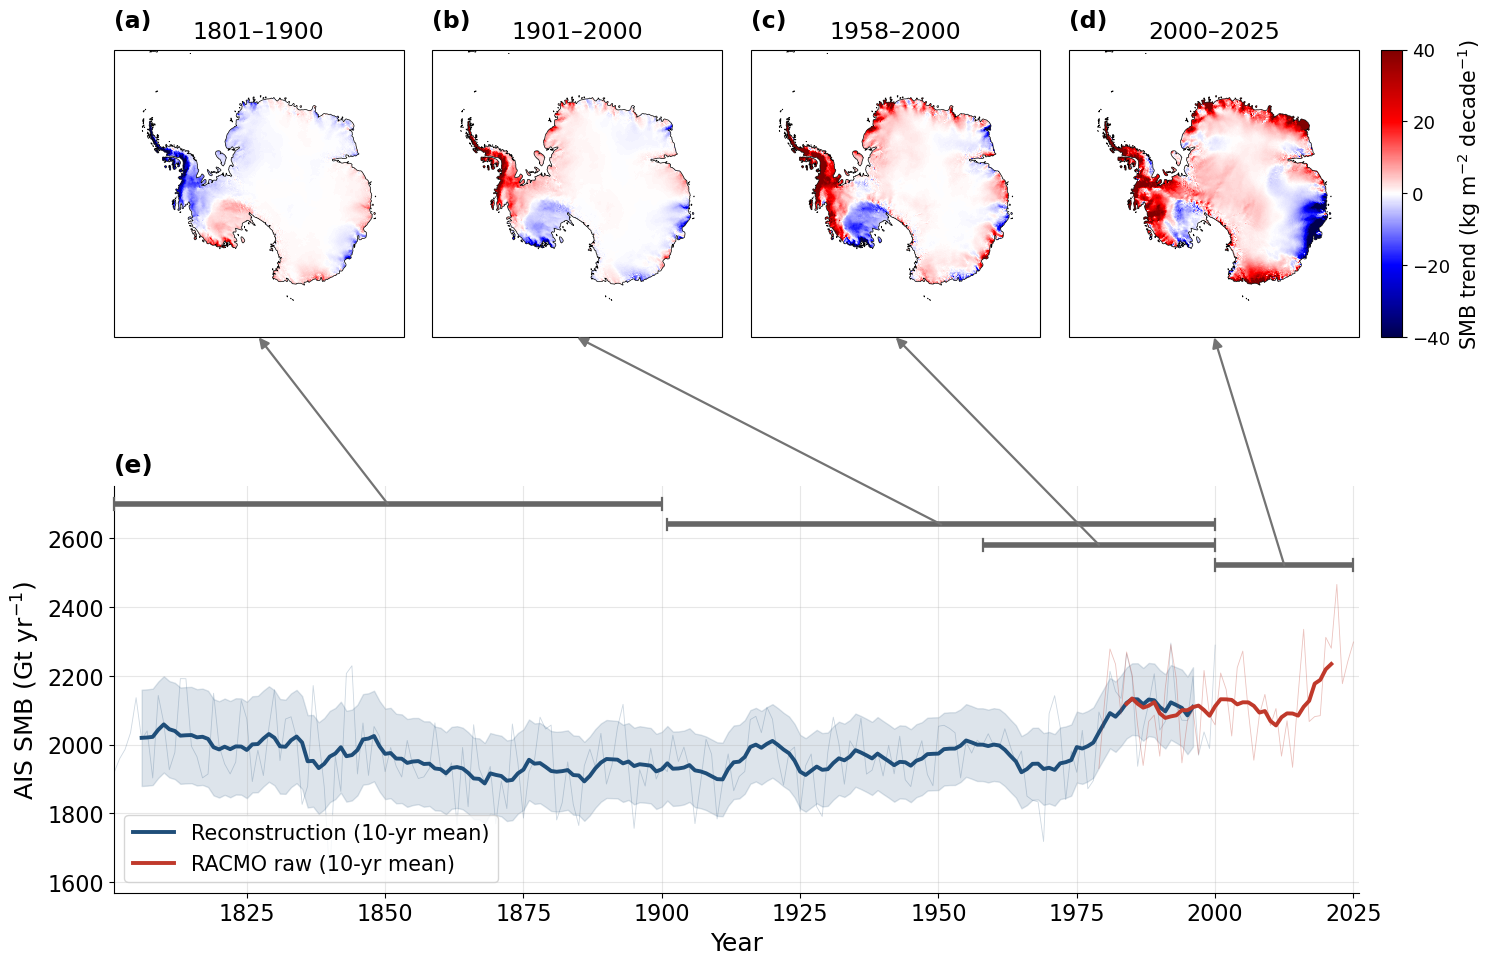

In [15]:
# ===== Stacked figure: AIS SMB time series + spatial-trend maps (true 10-yr mean, vertical cbar, arrows) =====
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs, cartopy.feature as cfeature
from matplotlib.transforms import blended_transform_factory
from matplotlib.patches import ConnectionPatch

def spatial_trend(cube, y0, y1, off):
    sub = cube[y0-off:y1-off+1]
    t = np.arange(sub.shape[0], dtype=float); X = np.vstack([t, np.ones_like(t)]).T
    beta, *_ = np.linalg.lstsq(X, sub.reshape(sub.shape[0], -1), rcond=None)
    return beta[0].reshape(sub.shape[1], sub.shape[2]) * 10
roll = lambda s, w=10: pd.Series(np.asarray(s, float)).rolling(w, center=True, min_periods=w).mean().values  # true 10-yr

# panel (c): reconstruction 1958–1978  +  raw RACMO 1979–2000
cube_c = np.concatenate([racmo_smb_recon[1958-1801:1979-1801],     # 1958–1978 (recon)
                         smb_ann.values[1979-1979:2000-1979+1]],   # 1979–2000 (RACMO)
                        axis=0)

C_REC, C_RAC = "#1f4e79", "#c0392b"; CMAP = "seismic"
periods = [("(a)", "1801–1900", racmo_smb_recon, 1801, 1900, 1801),
           ("(b)", "1901–2000", racmo_smb_recon, 1901, 2000, 1801),
           ("(c)", "1958–2000", cube_c,          1958, 2000, 1958),   # hybrid recon+RACMO
           ("(d)", "2000–2025", smb_ann.values,  2000, 2025, 1979)]

fig = plt.figure(figsize=(15, 10))
gs = gridspec.GridSpec(2, 4, height_ratios=[1.0, 1.35], hspace=0.40, wspace=0.10,
                       left=0.07, right=0.90, top=0.94, bottom=0.09)
map_axes = []
for j, (letter, yrs, cube, y0, y1, off) in enumerate(periods):
    axm = fig.add_subplot(gs[0, j], projection=ccrs.SouthPolarStereo()); map_axes.append(axm)
    axm.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
    im = axm.pcolormesh(lon_racmo, lat_racmo, spatial_trend(cube, y0, y1, off),
                        transform=ccrs.PlateCarree(), vmin=-40, vmax=40, cmap=CMAP, zorder=1)
    axm.add_feature(cfeature.OCEAN, facecolor="white", zorder=2)
    axm.add_feature(cfeature.COASTLINE, lw=0.5, zorder=3)
    axm.set_title(yrs, fontsize=17, pad=8, color="black")
    axm.text(0.0, 1.06, letter, transform=axm.transAxes, ha="left", va="bottom",
             fontsize=17, fontweight="bold", color="black")

p0 = map_axes[0].get_position(); p3 = map_axes[3].get_position()
cax = fig.add_axes([p3.x1 + 0.015, p3.y0, 0.014, p3.height])
cb = fig.colorbar(im, cax=cax, orientation="vertical")
cb.set_label("SMB trend (kg m$^{-2}$ decade$^{-1}$)", fontsize=15); cb.ax.tick_params(labelsize=13)

axt = fig.add_subplot(gs[1, :])
std = 2*smb_reg_std[:, 0]
axt.plot(recon_years, recon_series["AIS"], color=C_REC, lw=0.6, alpha=0.22)
axt.fill_between(recon_years, roll(recon_series["AIS"]-std), roll(recon_series["AIS"]+std), color=C_REC, alpha=0.15)
axt.plot(recon_years, roll(recon_series["AIS"]), color=C_REC, lw=2.8, label="Reconstruction (10-yr mean)")
axt.plot(raw_series["AIS"].index, raw_series["AIS"].values, color=C_RAC, lw=0.6, alpha=0.30)
axt.plot(raw_series["AIS"].index, roll(raw_series["AIS"].values), color=C_RAC, lw=2.8, label="RACMO raw (10-yr mean)")
axt.set_xlim(1801, 2026); axt.set_xlabel("Year", fontsize=18)
axt.set_ylabel("AIS SMB (Gt yr$^{-1}$)", fontsize=18)
axt.tick_params(labelsize=16); axt.grid(alpha=0.3); axt.legend(fontsize=15, loc="lower left")
for sp in ("top", "right"): axt.spines[sp].set_visible(False)
axt.text(0.0, 1.02, "(e)", transform=axt.transAxes, fontsize=18, fontweight="bold", va="bottom")

# --- neutral period bars + arrows linking each span to its map ---
_lo, _hi = axt.get_ylim(); axt.set_ylim(_lo, _hi + 0.26*(_hi-_lo))
trans = blended_transform_factory(axt.transData, axt.transAxes)
for (letter, _yrs, _cube, y0, y1, _off), axm, yl in zip(periods, map_axes, [0.955, 0.905, 0.855, 0.805]):
    axt.plot([y0, y1], [yl, yl], color="0.4", lw=4, solid_capstyle="butt", transform=trans, clip_on=False, zorder=6)
    for xx in (y0, y1):
        axt.plot([xx, xx], [yl-0.014, yl+0.014], color="0.4", lw=1.6, transform=trans, clip_on=False, zorder=6)
    con = ConnectionPatch(xyA=(0.5*(y0+y1), yl), coordsA=trans, xyB=(0.5, 0.0), coordsB=axm.transAxes,
                          arrowstyle="-|>", color="0.45", lw=1.6, mutation_scale=15, zorder=10)
    fig.add_artist(con)
plt.show()


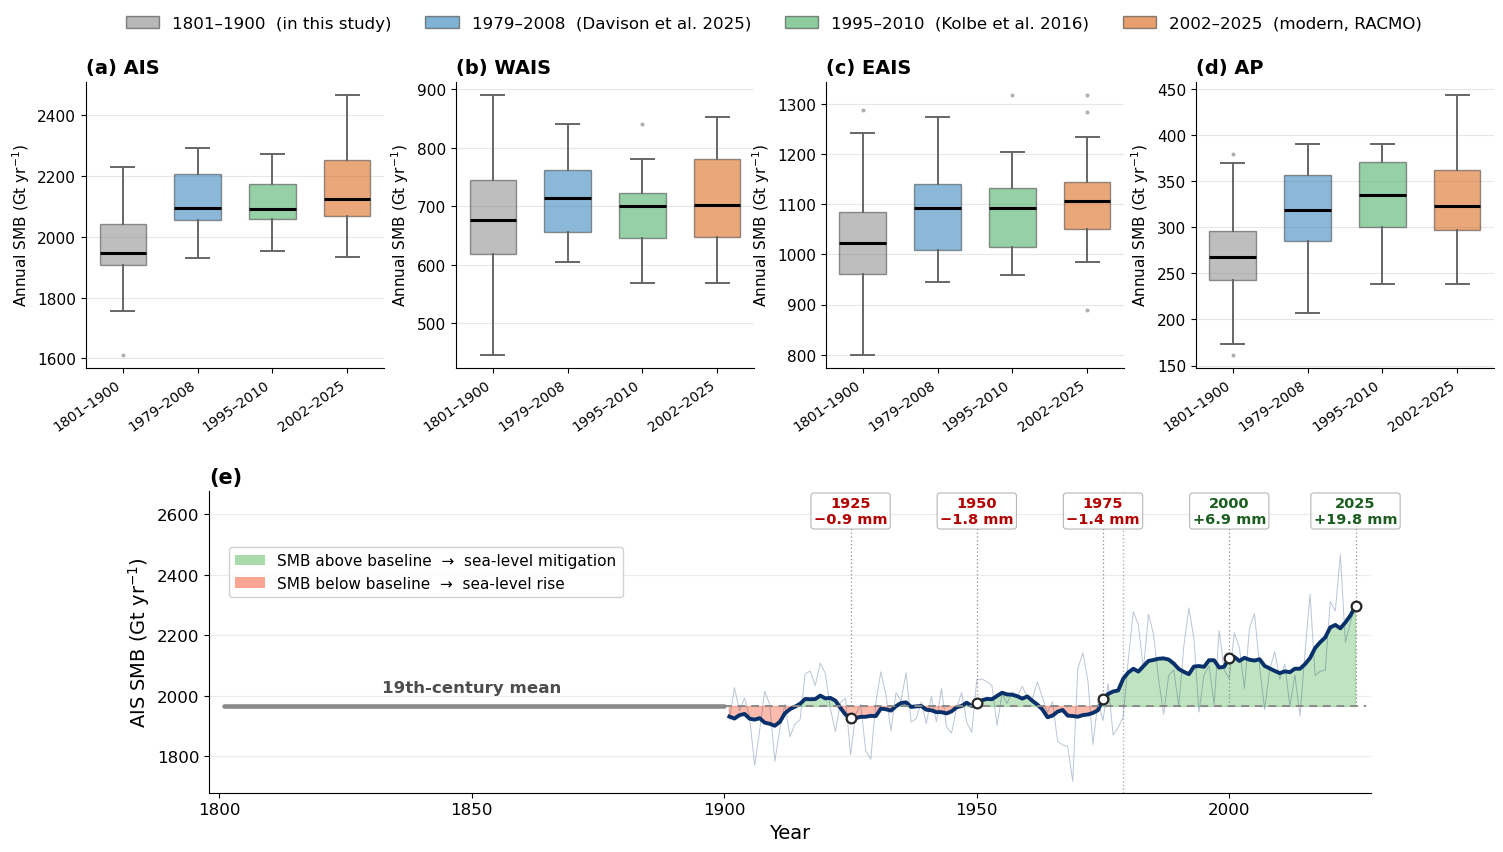

In [16]:
# ===== Regional boxplots (with study key) + AIS SMB 1901–2025 with 25-yr mitigation checkpoints =====
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
GT = 361.8

def region_vals(r, y0, y1, src):
    s = pd.Series(recon_series[r], index=recon_years) if src == "recon" else raw_series[r]
    return s.loc[y0:y1].values

periods4 = [("1801–1900", 1801, 1900, "recon"), ("1979–2008", 1979, 2008, "raw"),
            ("1995–2010", 1995, 2010, "raw"), ("2002–2025", 2002, 2025, "raw")]
PLAB4 = [p[0] for p in periods4]
PCOL4 = ["#8a8a8a", "#2C7FB8", "#41ab5d", "#D95F0E"]
STUDY = ["1801–1900  (in this study)", "1979–2008  (Davison et al. 2025)",
         "1995–2010  (Kolbe et al. 2016)", "2002–2025  (modern, RACMO)"]

fig = plt.figure(figsize=(16, 9))
gs = gridspec.GridSpec(2, 12, height_ratios=[0.95, 1.0], hspace=0.42, wspace=1.4,
                       left=0.07, right=0.95, top=0.88, bottom=0.09)
fig.legend(handles=[Patch(facecolor=PCOL4[i], alpha=0.6, edgecolor="0.25", label=STUDY[i]) for i in range(4)],
           loc="upper center", ncol=4, fontsize=12, frameon=False, bbox_to_anchor=(0.5, 0.97))

# --- row 0: regional boxplots (a)-(d) ---
for j, r in enumerate(region_names):
    axb = fig.add_subplot(gs[0, 3*j:3*j+3])
    data = [region_vals(r, y0, y1, src) for (_, y0, y1, src) in periods4]
    bp = axb.boxplot(data, positions=range(4), widths=0.62, patch_artist=True, manage_ticks=False,
                     medianprops=dict(color="black", lw=2.2), whiskerprops=dict(color="0.4", lw=1.4),
                     capprops=dict(color="0.4", lw=1.4), flierprops=dict(marker=".", ms=4, mfc="0.4", mec="0.4", alpha=0.4))
    for patch, c in zip(bp["boxes"], PCOL4):
        patch.set_facecolor(c); patch.set_alpha(0.55); patch.set_edgecolor("0.25")
    axb.set_xticks(range(4)); axb.set_xticklabels(PLAB4, rotation=35, ha="right", fontsize=10)
    axb.set_title(f"({chr(97+j)}) {r}", fontsize=14, fontweight="bold", loc="left")
    axb.set_ylabel("Annual SMB (Gt yr$^{-1}$)", fontsize=11)
    axb.tick_params(axis="y", labelsize=11); axb.grid(axis="y", alpha=0.3); axb.set_axisbelow(True)
    for sp in ("top", "right"): axb.spines[sp].set_visible(False)

# --- row 1 (e): AIS SMB 1901–2025, area = mitigation, with 25-yr checkpoints ---
axz = fig.add_subplot(gs[1, 1:11])
ais = pd.Series(recon_series["AIS"], index=recon_years); base = ais.loc[1801:1900].mean()
ts = pd.concat([ais.loc[1901:1978], raw_series["AIS"].loc[1979:2025]])
roll = lambda s: pd.Series(np.asarray(s, float)).rolling(11, center=True, min_periods=6).mean().values
rollv = roll(ts.values); C_TS, C_POS, C_NEG = "#08306b", "#74c476", "#fb6a4a"

axz.fill_between(ts.index, base, rollv, where=(rollv >= base), color=C_POS, alpha=0.45, interpolate=True, zorder=1)
axz.fill_between(ts.index, base, rollv, where=(rollv <  base), color=C_NEG, alpha=0.45, interpolate=True, zorder=1)
axz.plot([1801, 1900], [base, base], color=PCOL4[0], lw=3.3, solid_capstyle="round", zorder=4)
axz.plot([1900, 2027], [base, base], color=PCOL4[0], lw=1.4, ls=(0, (4, 3)), zorder=4)
axz.annotate("19th-century mean", (1850, base), textcoords="offset points", xytext=(0, 8),
             ha="center", va="bottom", fontsize=12, fontweight="bold", color="0.3")
axz.plot(ts.index, ts.values, color=C_TS, lw=0.7, alpha=0.28, zorder=2)
axz.plot(ts.index, rollv, color=C_TS, lw=2.8, zorder=3)
axz.axvline(1979, color="0.7", lw=1.0, ls=":", zorder=1)

allv = np.concatenate([ts.values, [base]]); span = np.ptp(allv)
lo_y, hi_y = allv.min() - 0.05*span, allv.max() + 0.28*span
axz.set_xlim(1798, 2028); axz.set_ylim(lo_y, hi_y)
y_lab = hi_y - 0.02*span
for cy in [1925, 1950, 1975, 2000, 2025]:
    cum = (ts.loc[1901:cy] - base).sum() / GT
    yc = np.interp(cy, ts.index, rollv)
    axz.plot([cy, cy], [base, y_lab - 0.10*span], color="0.55", lw=0.9, ls=(0, (1, 2)), zorder=3)
    axz.plot(cy, yc, "o", ms=7, mfc="white", mec="0.15", mew=1.6, zorder=5)
    axz.annotate(f"{cy}\n{'+' if cum >= 0 else '−'}{abs(cum):.1f} mm", (cy, y_lab), ha="center", va="top",
                 fontsize=10.5, fontweight="bold", color=("#1b5e20" if cum >= 0 else "#b30000"),
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="0.7", lw=0.8, alpha=0.95))
axz.set_xlabel("Year", fontsize=14); axz.set_ylabel("AIS SMB (Gt yr$^{-1}$)", fontsize=14)
axz.tick_params(labelsize=12); axz.grid(axis="y", alpha=0.25); axz.set_axisbelow(True)
for sp in ("top", "right"): axz.spines[sp].set_visible(False)
axz.legend(handles=[Patch(facecolor=C_POS, alpha=0.6, label="SMB above baseline  →  sea-level mitigation"),
                    Patch(facecolor=C_NEG, alpha=0.6, label="SMB below baseline  →  sea-level rise")],
           fontsize=11, loc="upper left", bbox_to_anchor=(0.01, 0.84), framealpha=0.9)
axz.set_title("(e)", fontsize=15, fontweight="bold", loc="left")
plt.show()


## 6 · Validation

Grid-cell skill map (|RACMO − reconstruction| in σ, 1979–2000), spatial correlation against ERA5/MERRA-2, and a reconstruction-vs-RACMO numeric check.

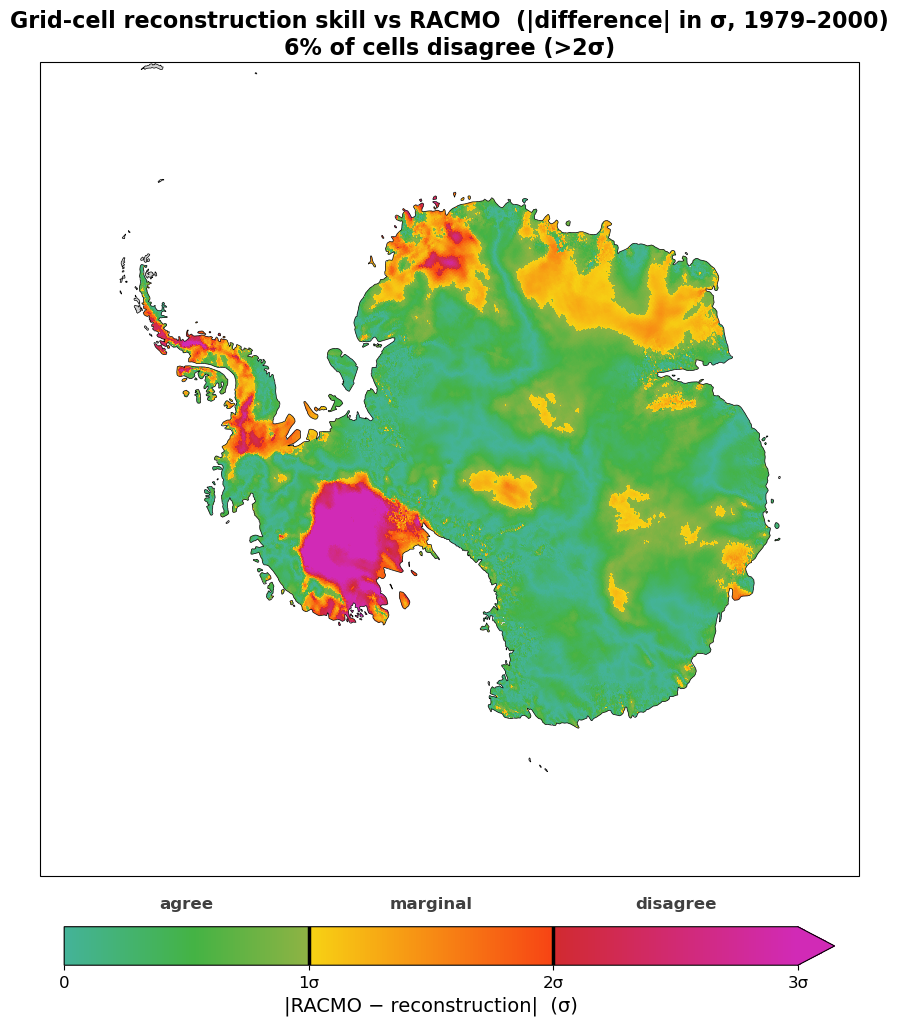

In [17]:
# ===== Skill-validation map at GRID-CELL resolution: |RACMO − recon| in σ (1979–2000) =====
import cartopy.crs as ccrs, cartopy.feature as cfeature
import colorsys
from matplotlib.colors import ListedColormap, Normalize

GT = 361.8
ibS, ipS, npy = slice(0, 100), slice(178, 200), 22          # baseline 1801–1900, window 1979–2000

# per-cell posterior std → (200, NY, NX)
s2 = np.full((200, NY*NX), np.nan, np.float32); s2[:, valid_cells] = smb_std_v
s2 = s2.reshape(200, NY, NX)

recon_win = racmo_smb_recon[ipS]                            # posterior-mean SMB, 1979–2000 (f=1 here)
racmo_win = smb_ann.sel(year=slice(1979, 2000)).values      # raw RACMO, same years
diff  = (racmo_win - recon_win).sum(0) / GT                 # window reconstruction error (baseline cancels)
var_m = (s2[ipS]**2).sum(0) + (npy/100.0)**2 * (s2[ibS]**2).sum(0)   # window + baseline variance (yrs indep.)
sig_m = np.sqrt(var_m) / GT
with np.errstate(divide="ignore", invalid="ignore"):
    zc = np.abs(diff) / sig_m
vmask2d = valid_cells.reshape(NY, NX)
zc[~vmask2d | ~np.isfinite(sig_m) | (sig_m <= 0)] = np.nan

ZCAP = 3.0
BANDS = [(0.0, 1.0, 0.46, 0.22, 0.62, 0.70),                # green : blue-green → yellow-green
         (1.0, 2.0, 0.14, 0.035, 0.92, 0.97),               # orange: yellow → orange
         (2.0, ZCAP, 0.995, 0.86, 0.80, 0.82)]              # red   : red → magenta
def band_color(z):
    if not np.isfinite(z): return (0.93, 0.93, 0.93, 1.0)
    for zlo, zhi, h0, h1, S, V in BANDS:
        if z < zhi or zhi == ZCAP:
            f = np.clip((z - zlo) / (zhi - zlo), 0, 1)
            return (*colorsys.hsv_to_rgb((h0 + f*(h1 - h0)) % 1.0, S, V), 1.0)
grad = ListedColormap([band_color(x) for x in np.linspace(0, ZCAP, 300)]); norm = Normalize(0, ZCAP)

proj = ccrs.SouthPolarStereo()
fig, ax = plt.subplots(figsize=(11, 11), subplot_kw={"projection": proj})
ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
im = ax.pcolormesh(lon_racmo, lat_racmo, zc, transform=ccrs.PlateCarree(),
                   cmap=grad, norm=norm, shading="nearest", zorder=1)
ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=2)
ax.add_feature(cfeature.COASTLINE, lw=0.5, zorder=3)

cb = fig.colorbar(im, ax=ax, orientation="horizontal", pad=0.05, shrink=0.72, extend="max")
cb.set_ticks([0, 1, 2, 3]); cb.set_ticklabels(["0", "1σ", "2σ", "3σ"])
cb.set_label("|RACMO − reconstruction|  (σ)", fontsize=14); cb.ax.tick_params(labelsize=12)
for xb in (1, 2): cb.ax.axvline(xb, color="black", lw=2.5)
tr = cb.ax.get_xaxis_transform()
for xc, lab in [(0.5, "agree"), (1.5, "marginal"), (2.5, "disagree")]:
    cb.ax.text(xc, 1.4, lab, transform=tr, ha="center", va="bottom", fontsize=12, fontweight="bold", color="0.25")
frac2 = np.isfinite(zc) & (zc > 2)
ax.set_title(f"Grid-cell reconstruction skill vs RACMO  (|difference| in σ, 1979–2000)\n"
             f"{100*np.nansum(frac2)/np.isfinite(zc).sum():.0f}% of cells disagree (>2σ)",
             fontsize=16, fontweight="bold")
plt.tight_layout(); plt.show()


/var/folders/4d/5th1wr_s21g614c74mcbh9kc0000gn/T/ipykernel_45822/4044980501.py:44: RuntimeWarning: Mean of empty slice
  grounded = ~np.isnan(np.nanmean(racmo_smb_recon[:100], axis=0))     # 1801–1900 mean finite = grounded cell
/var/folders/4d/5th1wr_s21g614c74mcbh9kc0000gn/T/ipykernel_45822/4044980501.py:11: RuntimeWarning: Mean of empty slice
  ra = rec - np.nanmean(rec, axis=0); oa = obs - np.nanmean(obs, axis=0)
/var/folders/4d/5th1wr_s21g614c74mcbh9kc0000gn/T/ipykernel_45822/4044980501.py:11: RuntimeWarning: Mean of empty slice
  ra = rec - np.nanmean(rec, axis=0); oa = obs - np.nanmean(obs, axis=0)


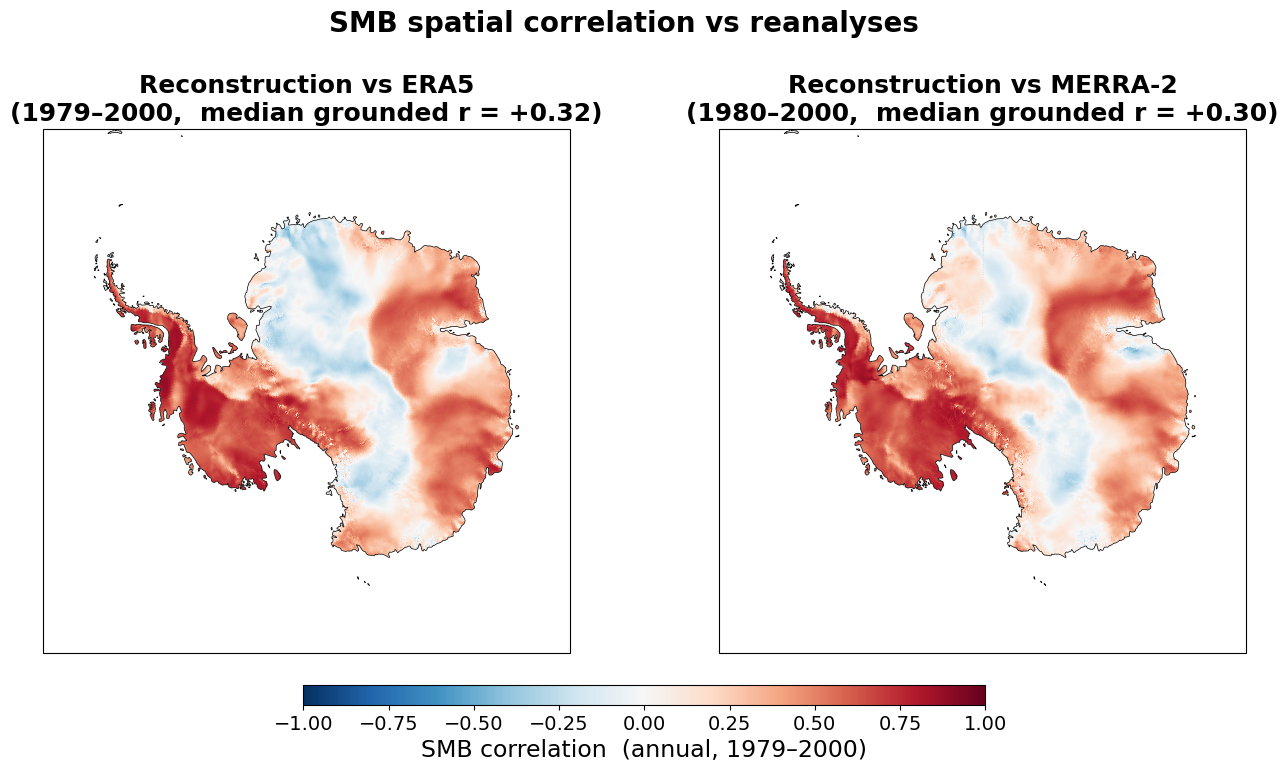

In [18]:
# ===== SMB spatial correlation vs reanalyses (1979–2000): ERA5 + MERRA-2 =====
# ERA5: gridded total precipitation (tp, 0.1°).  MERRA-2: gridded PRECTOT (flux collection).
# For an interannual per-cell correlation, precip vs P–E is effectively identical (sublimation
# anomalies are small), so we correlate reconstructed SMB against reanalysis precipitation.
import glob
import cartopy.crs as ccrs, cartopy.feature as cfeature
from scipy.interpolate import RegularGridInterpolator
data_dir = os.path.expanduser("~/DataFiles")

def spatial_corr(rec, obs):
    ra = rec - np.nanmean(rec, axis=0); oa = obs - np.nanmean(obs, axis=0)
    num = np.nansum(ra*oa, axis=0); den = np.sqrt(np.nansum(ra**2, axis=0)*np.nansum(oa**2, axis=0))
    with np.errstate(invalid="ignore"): return np.where(den > 0, num/den, np.nan)

def regrid_to_ant11(slat, slon, vals):
    """vals (T, nlat, nlon) on (slat, slon) → (T, NY, NX) on the ANT11 grid. Robust to lon convention."""
    slon = slon % 360
    if slat[0] > slat[-1]: slat = slat[::-1]; vals = vals[:, ::-1, :]
    o = np.argsort(slon); slon = slon[o]; vals = vals[:, :, o]
    slon = np.concatenate([slon, [slon[0] + 360]])                  # periodic wrap in longitude
    vals = np.concatenate([vals, vals[:, :, :1]], axis=2)
    qlat = np.clip(lat_racmo.ravel(), slat.min(), slat.max()); qlon = lon_racmo.ravel() % 360
    pts = np.stack([qlat, qlon], -1)
    out = np.empty((vals.shape[0], NY, NX))
    for t in range(vals.shape[0]):
        out[t] = RegularGridInterpolator((slat, slon), vals[t], bounds_error=False,
                                         fill_value=np.nan)(pts).reshape(NY, NX)
    return out

# --- ERA5 gridded annual precip (tp, m/month-rate → annual total) ---
e5 = xr.open_dataset(data_dir + "/ae3baa6a74f0aa315dc3de6f83298f0e.nc").sel(valid_time=slice("1979", "2000"))
e5_ann = ((e5["tp"] * e5["valid_time"].dt.days_in_month).groupby("valid_time.year").sum("valid_time"))
era5_ann = regrid_to_ant11(e5["latitude"].values, e5["longitude"].values, e5_ann.values)   # (Ny,NY,NX)
era5_years = e5_ann["year"].values

# --- MERRA-2 gridded annual precip (PRECTOT, kg m⁻² s⁻¹ → annual total) ---
mfiles = sorted(f for f in glob.glob(data_dir + "/M2TMNXFLX/*") if f.endswith((".nc4", ".dap.nc4")))
m2 = xr.concat([xr.open_dataset(f) for f in mfiles], dim="time")
m2_ann = ((m2["PRECTOT"] * m2["time"].dt.days_in_month * 86400.0)
          .groupby("time.year").sum("time").sel(year=slice(1979, 2000)))
merra_ann = regrid_to_ant11(m2["lat"].values, m2["lon"].values, m2_ann.values)
merra_years = m2_ann["year"].values

grounded = ~np.isnan(np.nanmean(racmo_smb_recon[:100], axis=0))     # 1801–1900 mean finite = grounded cell
fig, axes = plt.subplots(1, 2, figsize=(16, 8.5), subplot_kw={"projection": ccrs.SouthPolarStereo()})
im = None
for ax, (src, cube, yrs) in zip(axes, [("ERA5", era5_ann, era5_years), ("MERRA-2", merra_ann, merra_years)]):
    yrs = [int(y) for y in yrs if 1979 <= y <= 2000]
    rec = racmo_smb_recon[[y-1801 for y in yrs]]
    obs = cube[[list(era5_years if src=="ERA5" else merra_years).index(y) for y in yrs]]
    corr = spatial_corr(rec, obs); corr[~grounded] = np.nan
    ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor="0.9", zorder=0)
    im = ax.pcolormesh(lon_racmo, lat_racmo, corr, transform=ccrs.PlateCarree(),
                       vmin=-1, vmax=1, cmap="RdBu_r", shading="nearest", zorder=1)
    ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=2)
    ax.add_feature(cfeature.COASTLINE, lw=0.5, zorder=3)
    ax.set_title(f"Reconstruction vs {src}\n({yrs[0]}–{yrs[-1]},  median grounded r = {np.nanmedian(corr):+.2f})",
                 fontsize=18, fontweight="bold")
cb = fig.colorbar(im, ax=axes, orientation="horizontal", pad=0.05, shrink=0.55, aspect=35)
cb.set_label("SMB correlation  (annual, 1979–2000)", fontsize=17); cb.ax.tick_params(labelsize=14)
fig.suptitle("SMB spatial correlation vs reanalyses", fontsize=20, fontweight="bold", y=1.02)
plt.show()


In [19]:
b = 10; GT = 361.8
base = smb_basin_recon[b].loc[1801:1900].mean()
rc = smb_basin_recon[b].loc[1979:2000]; ra = smb_basin_obs[b].loc[1979:2000]
yr = np.arange(1979, 2001)
print(f"baseline (recon 1801–1900) : {base:8.2f} Gt/yr")
print(f"recon  1979–2000 mean       : {rc.mean():8.2f}   RACMO mean : {ra.mean():8.2f}   (recon−RACMO = {rc.mean()-ra.mean():+.2f})")
print(f"mitigation  recon           : {(rc-base).sum()/GT:+.3f} mm   RACMO : {(ra-base).sum()/GT:+.3f} mm")
print(f"slope  recon                : {np.polyfit(yr, rc.values,1)[0]:+.3f} Gt/yr²   RACMO : {np.polyfit(yr, ra.values,1)[0]:+.3f} Gt/yr²")


baseline (recon 1801–1900) :   141.90 Gt/yr
recon  1979–2000 mean       :   140.20   RACMO mean :   131.19   (recon−RACMO = +9.01)
mitigation  recon           : -0.103 mm   RACMO : -0.651 mm
slope  recon                : -1.941 Gt/yr²   RACMO : -0.832 Gt/yr²


## 7 · Natural variability and emergence (GGM null)

GGM helpers, the committed 1801–1900 red fit (`ggm_fits_red`), the **variance-matched** null (`ggm_fits_vm`, marginal σ set equal to the reconstruction's 1801–1900 σ), the sea-level-mitigation emergence figure (Figure 3), and the variance-match robustness table.

In [20]:
def _ggm_psi(kappa, phi, K):
    d = 0.5*kappa; a = 1.0-phi; psi = np.empty(K); psi[0] = 1.0
    for k in range(1, K): psi[k] = psi[k-1]*(d+k-1.0)/k*a
    return psi
def _ggm_acf(kappa, phi, n, K=None):
    if K is None: K = int(min(20000, max(2000, 30*n if phi > 0.02 else 20000)))
    psi = _ggm_psi(kappa, phi, K+n)
    return np.array([np.dot(psi[:K], psi[h:h+K]) for h in range(n)])
def _toeplitz(r):
    n = len(r); idx = np.abs(np.arange(n)[:, None] - np.arange(n)[None, :]); return r[idx]
def ggm_fit(x, kappa0=1.0, phi0=0.1, bounds=((0.0,4.0),(1e-4,1.0))):
    from scipy.optimize import minimize
    x = np.asarray(x, float); x = x - x.mean(); n = len(x)
    def negll(th):
        r = _ggm_acf(th[0], th[1], n)
        try: L = np.linalg.cholesky(_toeplitz(r))
        except np.linalg.LinAlgError: return 1e12
        z = np.linalg.solve(L, x); s2 = (z@z)/n
        return 0.5*(n*np.log(2*np.pi*s2) + 2.0*np.log(np.diag(L)).sum() + n)
    res = minimize(negll, [kappa0, phi0], method="L-BFGS-B", bounds=bounds)
    r = _ggm_acf(*res.x, n); L = np.linalg.cholesky(_toeplitz(r)); z = np.linalg.solve(L, x)
    return dict(kappa=res.x[0], phi=res.x[1], sigma_w=np.sqrt((z@z)/n))

ggm_fits = {}
for k, r in enumerate(region_names):
    f_raw = ggm_fit(smb_reg_mean_raw[0:100, k])                    # SHAPE from RAW mean (old)
    f     = ggm_fit(smb_reg_mean[0:100, k])                        # SHAPE from VARIANCE-CORRECTED mean (new)
    marg = np.sqrt(_ggm_acf(f["kappa"], f["phi"], 1)[0]) * f["sigma_w"]
    f["sigma_w"] *= sig_total_ltv[r] / marg                        # AMPLITUDE from LTV (unchanged)
    ggm_fits[r] = f
    print(f"{r}: kappa {f['kappa']:.2f} (raw was {f_raw['kappa']:.2f})  phi {f['phi']:.3f}  "
          f"sigma_w {f['sigma_w']:.1f}  (= LTV {sig_total_ltv[r]:.1f})")





AIS: kappa 0.00 (raw was 0.00)  phi 1.000  sigma_w 108.0  (= LTV 108.0)
WAIS: kappa 0.00 (raw was 0.00)  phi 1.000  sigma_w 85.7  (= LTV 85.7)
EAIS: kappa 0.00 (raw was 0.00)  phi 1.000  sigma_w 90.1  (= LTV 90.1)
AP: kappa 0.63 (raw was 0.63)  phi 0.014  sigma_w 32.6  (= LTV 36.4)


In [21]:
# ===== GGM refit: multi-start, with a forced-red diagnostic vs the degenerate white fit =====
from scipy.optimize import minimize
def _negll(th, x, n):
    r = _ggm_acf(th[0], th[1], n)
    try: L = np.linalg.cholesky(_toeplitz(r))
    except np.linalg.LinAlgError: return 1e12
    z = np.linalg.solve(L, x); s2 = (z@z)/n
    return 0.5*(n*np.log(2*np.pi*s2) + 2*np.log(np.diag(L)).sum() + n)
def fit_ggm(x, red=False):
    x = np.asarray(x, float); x = x - x.mean(); n = len(x)
    lo_k, hi_p = (0.05, 0.95) if red else (1e-3, 1.0)                 # 'red' path forbids the white corner
    starts = [(1.0,0.1),(0.6,0.05),(2.0,0.02),(0.3,0.3),(1.5,0.5),(0.8,0.02),(0.4,0.1)]
    best = None
    for k0, p0 in starts:
        res = minimize(_negll, [max(k0,lo_k), min(p0,hi_p)], args=(x,n),
                       method="L-BFGS-B", bounds=((lo_k,4.0),(1e-4,hi_p)))
        if best is None or res.fun < best.fun: best = res
    r = _ggm_acf(*best.x, n); L = np.linalg.cholesky(_toeplitz(r)); z = np.linalg.solve(L, x)
    return dict(kappa=best.x[0], phi=best.x[1], sigma_w=np.sqrt((z@z)/n), negll=best.fun)

print(f"{'region':<6}{'free κ':>8}{'free φ':>8}{'nLL':>9}{'red κ':>8}{'red φ':>8}{'nLL':>9}{'ΔnLL':>7}   ACF1 emp/red")
ggm_fits_red = {}
for r in region_names:
    x = np.asarray(recon_series[r])[:100]
    ff = fit_ggm(x, red=False)                                        # free multi-start (may still be white)
    fr = fit_ggm(x, red=True)                                         # forced non-degenerate
    ar = _ggm_acf(fr['kappa'], fr['phi'], 2); acf1_red = ar[1]/ar[0]
    sd = x - np.polyval(np.polyfit(np.arange(100), x, 1), np.arange(100))
    acf1_emp = np.corrcoef(sd[:-1], sd[1:])[0, 1]
    marg = np.sqrt(_ggm_acf(fr['kappa'], fr['phi'], 1)[0]) * fr['sigma_w']
    fr['sigma_w'] *= sig_total_ltv[r] / marg                          # keep LTV amplitude (isolate persistence effect)
    ggm_fits_red[r] = fr
    print(f"{r:<6}{ff['kappa']:>8.2f}{ff['phi']:>8.3f}{ff['negll']:>9.2f}"
          f"{fr['kappa']:>8.2f}{fr['phi']:>8.3f}{fr['negll']:>9.2f}{fr['negll']-ff['negll']:>7.2f}   {acf1_emp:>5.2f}/{acf1_red:.2f}")


region  free κ  free φ      nLL   red κ   red φ      nLL   ΔnLL   ACF1 emp/red
AIS       4.00   0.898   609.22    4.00   0.898   609.22  -0.00    0.11/0.20
WAIS      4.00   0.947   589.83    4.00   0.947   589.83   0.00    0.09/0.10
EAIS      4.00   0.839   590.34    4.00   0.839   590.34  -0.00    0.28/0.31
AP        0.63   0.014   508.40    0.63   0.014   508.40   0.00    0.19/0.40


In [22]:
# ===== variance-matched GGM nulls (marginal σ = reconstruction's 1801–1900 σ) =====
def _vm(r):
    fit = dict(ggm_fits_red[r])
    imp = np.sqrt(_ggm_acf(fit["kappa"], fit["phi"], 1)[0] * fit["sigma_w"]**2)
    emp = pd.Series(recon_series[r], index=recon_years).loc[1801:1900].std()
    fit["sigma_w"] *= emp / imp
    return fit
ggm_fits_vm = {r: _vm(r) for r in region_names}
print("variance-matched σ_w:", {r: round(ggm_fits_vm[r]["sigma_w"], 1) for r in region_names})


variance-matched σ_w: {'AIS': np.float64(107.5), 'WAIS': np.float64(88.6), 'EAIS': np.float64(88.5), 'AP': np.float64(40.3)}


region emergence
AIS         2009
WAIS        None
EAIS        None
AP          None


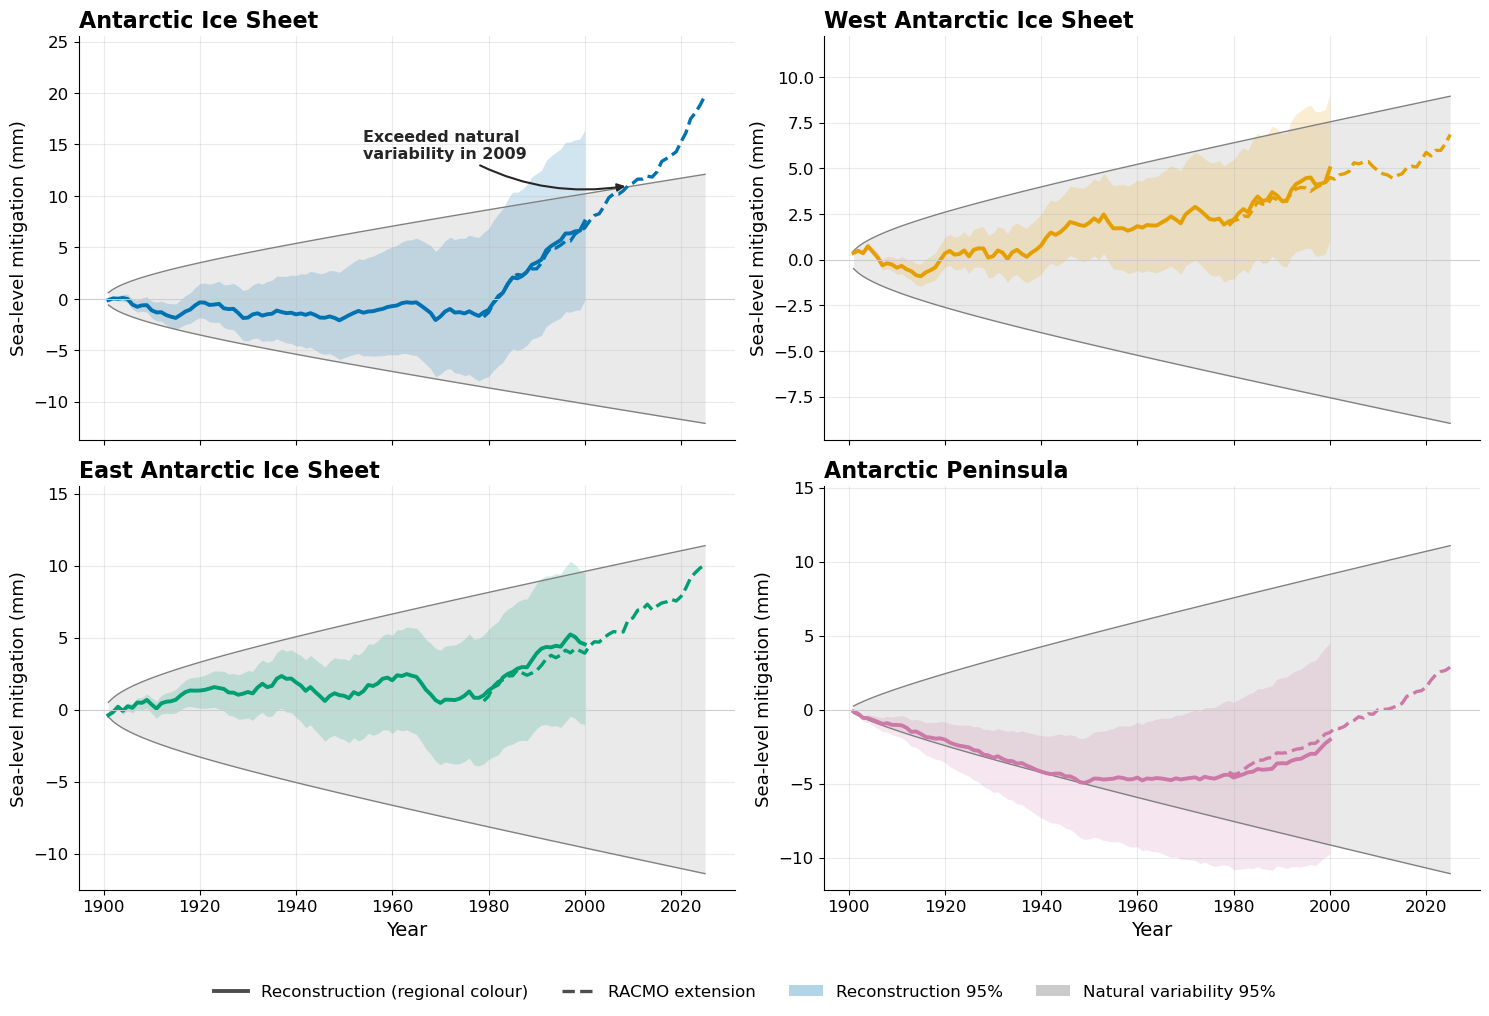

In [23]:
# ===== Figure 3: sea-level mitigation vs GGM natural-variability null (variance-matched) =====
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
GT = 361.8; NB, NA = 100, 125
CB = {"AIS":"#0072B2","WAIS":"#E69F00","EAIS":"#009E73","AP":"#CC79A7"}
FULL = {"AIS":"Antarctic Ice Sheet","WAIS":"West Antarctic Ice Sheet",
        "EAIS":"East Antarctic Ice Sheet","AP":"Antarctic Peninsula"}
region_idx = {"AIS":0,"WAIS":1,"EAIS":2,"AP":3}
def sea_level_mitigation(ts, b=slice(0,100)):
    ts = np.asarray(ts, float); return np.cumsum(ts - ts[b].mean())/GT
def extend_slm(recon_ts, obs_ts, b=slice(0,100)):
    r = np.asarray(recon_ts, float); base = r[b].mean(); return np.sum(r[:178]-base)/GT + np.cumsum((np.asarray(obs_ts)-base)/GT)
def slm_sigma(fit):
    R = _toeplitz(_ggm_acf(fit["kappa"], fit["phi"], NB+NA) * fit["sigma_w"]**2)
    return np.array([np.sqrt((a:=np.concatenate([np.full(NB,-n/NB),np.ones(n)])) @ R[:NB+n,:NB+n] @ a)/GT for n in range(1,NA+1)])
def emergence(traj, sig, years, minsus=8):
    out = traj > 1.96*sig
    for i in range(len(years)):
        if out[i:].all():
            return int(years[i]) if (len(years)-i >= minsus and years[i] <= 2025-minsus) else None
    return None

GGM = ggm_fits_vm                                       # variance-matched null
years, cent, yr_obs = np.arange(1901,2026), np.arange(1901,2001), np.arange(1979,2026)
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
print(f"{'region':<6}{'emergence':>10}")
for ax, r in zip(axes.ravel(), region_names):
    k = region_idx[r]; col = CB[r]
    recon_ts = np.asarray(recon_series[r]); obs_ts = raw_series[r].loc[1979:2025].values
    slm_recon = sea_level_mitigation(recon_ts); slm_ext = extend_slm(recon_ts, obs_ts)
    traj = np.concatenate([slm_recon[100:178], slm_ext]); sig = slm_sigma(GGM[r])
    slm_mem = np.stack([sea_level_mitigation(smb_reg_ens[:, m, k]) for m in range(smb_reg_ens.shape[1])])
    lo, hi = np.percentile(slm_mem, [2.5, 97.5], axis=0)
    cy = emergence(traj, sig, years); print(f"{r:<6}{str(cy):>10}")

    ax.fill_between(years, -1.96*sig, 1.96*sig, color="0.6", alpha=0.20, lw=0)
    ax.plot(years, 1.96*sig, color="0.5", lw=1.0); ax.plot(years, -1.96*sig, color="0.5", lw=1.0)
    ax.fill_between(cent, lo[100:200], hi[100:200], color=col, alpha=0.18, lw=0)
    ax.plot(cent, slm_recon[100:200], color=col, lw=2.8)
    ax.plot(yr_obs, slm_ext, color=col, lw=2.4, ls="--")
    ax.axhline(0, color="0.8", lw=0.7)
    if cy is not None:
        yv = traj[cy-1901]
        ax.annotate(f"Exceeded natural\nvariability in {cy}", xy=(cy, yv), xytext=(cy-55, yv+0.18*np.ptp(traj)),
                    fontsize=11.5, fontweight="bold", color="0.15", ha="left", va="center",
                    arrowprops=dict(arrowstyle="-|>", color="0.15", lw=1.5, connectionstyle="arc3,rad=0.2"))
    ax.set_title(FULL[r], fontsize=16, fontweight="bold", loc="left")
    ax.set_ylabel("Sea-level mitigation (mm)", fontsize=13); ax.tick_params(labelsize=12); ax.grid(alpha=0.25)
    lo_, hi_ = ax.get_ylim(); ax.set_ylim(lo_, hi_ + 0.12*(hi_-lo_))
    for sp in ("top","right"): ax.spines[sp].set_visible(False)
for ax in axes[-1, :]: ax.set_xlabel("Year", fontsize=14)
handles = [Line2D([0],[0], color="0.3", lw=2.8, label="Reconstruction (regional colour)"),
           Line2D([0],[0], color="0.3", lw=2.4, ls="--", label="RACMO extension"),
           Patch(facecolor=CB["AIS"], alpha=0.3, label="Reconstruction 95%"),
           Patch(facecolor="0.6", alpha=0.5, label="Natural variability 95%")]
fig.legend(handles=handles, loc="lower center", ncol=4, frameon=False, fontsize=12, bbox_to_anchor=(0.5, -0.02))
fig.tight_layout(rect=[0, 0.04, 1, 1]); plt.show()


In [24]:
# ===== Does variance-matching the null change emergence? (all regions) =====
GT=361.8; NB,NA=100,125
def sea_level_mitigation(ts,b=slice(0,100)):
    ts=np.asarray(ts,float); return np.cumsum(ts-ts[b].mean())/GT
def extend_slm(recon_ts,obs_ts,b=slice(0,100)):
    r=np.asarray(recon_ts,float); base=r[b].mean(); return np.sum(r[:178]-base)/GT+np.cumsum((np.asarray(obs_ts)-base)/GT)
def slm_sigma(fit):
    R=_toeplitz(_ggm_acf(fit["kappa"],fit["phi"],NB+NA)*fit["sigma_w"]**2)
    return np.array([np.sqrt((a:=np.concatenate([np.full(NB,-n/NB),np.ones(n)]))@R[:NB+n,:NB+n]@a)/GT for n in range(1,NA+1)])
def emg(traj,sig,years,minsus=8):
    out=traj>1.96*sig
    for i in range(len(years)):
        if out[i:].all() and (len(years)-i)>=minsus and years[i]<=2025-minsus: return int(years[i])
    return None

years=np.arange(1901,2026)
print(f"{'region':<6}{'GGM σ':>8}{'emp σ':>8}{'ratio':>7}{'emerg orig':>12}{'emerg matched':>15}")
for r in region_names:
    fit=dict(ggm_fits_red[r])
    imp=np.sqrt(_ggm_acf(fit["kappa"],fit["phi"],1)[0]*fit["sigma_w"]**2)
    emp=pd.Series(recon_series[r],index=recon_years).loc[1801:1900].std()
    fit_v=dict(fit); fit_v["sigma_w"]=fit["sigma_w"]*emp/imp
    recon_ts=np.asarray(recon_series[r]); obs_ts=raw_series[r].loc[1979:2025].values
    traj=np.concatenate([sea_level_mitigation(recon_ts)[100:178], extend_slm(recon_ts,obs_ts)])
    e0,e1=emg(traj,slm_sigma(fit),years),emg(traj,slm_sigma(fit_v),years)
    print(f"{r:<6}{imp:>8.1f}{emp:>8.1f}{emp/imp:>7.2f}{str(e0):>12}{str(e1):>15}")


region   GGM σ   emp σ  ratio  emerg orig  emerg matched
AIS      108.0   109.8   1.02        2009           2009
WAIS      85.7    89.1   1.04        None           None
EAIS      90.1    93.3   1.04        None           None
AP        36.4    45.1   1.24        None           None


## 8 · Attribution — SAM and temperature

Congruence attribution setup (Gong–Wang 20CRv3 SAM for the sensitivity β, Marshall SAM for the trend; RACMO-calibrated temperature sensitivity), the independent Bromwich/Nicolas T2m reconstruction, and the trend-decomposition figure with the sea-level-mitigation waterfall over the **1958–2025 attribution window**.

In [25]:
# ===== SAM/temperature attribution — setup: Gong–Wang (20CRv3) β + Marshall trend, per-cell sensitivities =====
import os, urllib.request
# --- Marshall (2003) station SAM: used for the long-term (1958–2000) trend ---
sam_path = os.path.expanduser("~/DataFiles/marshall_sam.txt")
if not os.path.exists(sam_path):
    urllib.request.urlretrieve("http://www.nerc-bas.ac.uk/public/icd/gjma/newsam.1957.2007.txt", sam_path)
_raw = pd.read_csv(sam_path, sep=r"\s+", header=0, index_col=0)
sam_marshall = _raw.apply(pd.to_numeric, errors="coerce").dropna().mean(axis=1); sam_marshall.index = sam_marshall.index.astype(int)

# --- Gong & Wang (1999) reanalysis SAM from 20CRv3 (SLP 40°S−65°S, standardized): used for β ---
gw_path = os.path.expanduser("~/DataFiles/sam.20crv3.long.data")
if not os.path.exists(gw_path):
    urllib.request.urlretrieve("https://psl.noaa.gov/data/20thC_Rean/timeseries/monthly/SAM/sam.20crv3.long.data", gw_path)
rows = []
with open(gw_path) as f:
    y0, y1 = (int(x) for x in f.readline().split())
    for line in f:
        p = line.split()
        if len(p) != 13 or not p[0].lstrip("-").isdigit(): break
        yr = int(p[0])
        if yr < y0 or yr > y1: break
        v = np.array([float(x) for x in p[1:]]); v[v <= -90] = np.nan
        rows.append((yr, np.nanmean(v)))
sam_gw_raw = pd.Series(dict(rows))

# --- standardize BOTH annual indices to unit variance over a common window → consistent "per 1σ" units ---
def zscore(s, ref=slice(1979, 2000)):
    r = s.loc[ref]; return (s - r.mean()) / r.std(ddof=1)
sam = zscore(sam_marshall)        # standardized Marshall → drives the 1958–2000 trend (downstream cells)
sam_gw = zscore(sam_gw_raw)       # standardized Gong–Wang → drives the sensitivity β

def detrend_cols(A):
    t = np.arange(A.shape[0], dtype=float); tc = t - t.mean()
    return A - A.mean(0) - tc[:, None] * ((tc[:, None]*A).sum(0)/(tc@tc))[None, :]
def trend_cols(A):
    t = np.arange(A.shape[0], dtype=float); tc = t - t.mean()
    return (tc[:, None] * A).sum(0) / (tc @ tc)
def _cols(da, y0, y1, scale=1.0):
    return da.sel(year=slice(y0, y1)).values.reshape(y1-y0+1, -1)[:, valid_cells] * scale
def paint_cells(v): f = np.full(NY*NX, np.nan); f[valid_cells] = v; return f.reshape(NY, NX)
def rc(a, b): m = np.isfinite(a) & np.isfinite(b); return np.corrcoef(a[m], b[m])[0, 1]
def _detr(x): x = np.asarray(x, float); return x - np.polyval(np.polyfit(np.arange(len(x)), x, 1), np.arange(len(x)))

# --- per-cell interannual sensitivities over the reanalysis era (β from Gong–Wang; keep Marshall β for comparison) ---
SAM_END = int(min(sam_gw.index.max(), 2014))                                   # 20CRv3 ends 2014
smb_rd   = detrend_cols(_cols(smb_ann, 1979, SAM_END))                          # SMB over the β window
smb_rd25 = detrend_cols(_cols(smb_ann, 1979, 2025))
t2m_rd   = detrend_cols(_cols(t2m_ann, 1979, 2025))
gw_sd  = _detr(sam_gw.reindex(np.arange(1979, SAM_END+1)).values)
mar_sd = _detr(sam.reindex(np.arange(1979, SAM_END+1)).values)
SAMsens_rate   = (gw_sd[:, None]  * smb_rd).sum(0) / (gw_sd  @ gw_sd)           # β from Gong–Wang (M&T choice, DEFAULT)
SAMsens_rate_M = (mar_sd[:, None] * smb_rd).sum(0) / (mar_sd @ mar_sd)          # β from Marshall (for comparison)
Tsens_rate     = (t2m_rd * smb_rd25).sum(0) / (t2m_rd * t2m_rd).sum(0)          # mm w.e. yr⁻¹ per K

print(f"β window 1979–{SAM_END} | GW–Marshall annual r (1979–{SAM_END}) = "
      f"{np.corrcoef(sam_gw.loc[1979:SAM_END], sam.loc[1979:SAM_END])[0,1]:.2f}")
print(f"β-pattern spatial corr (GW vs Marshall) = {rc(SAMsens_rate, SAMsens_rate_M):.2f}")
print(f"standardized Marshall SAM trend 1958–2000 = {np.polyfit(np.arange(43), sam.loc[1958:2000].values, 1)[0]*10:.2f} σ/dec")


β window 1979–2014 | GW–Marshall annual r (1979–2014) = 0.87
β-pattern spatial corr (GW vs Marshall) = 0.98
standardized Marshall SAM trend 1958–2000 = 0.28 σ/dec


In [26]:
# ===== Load Bromwich reconstructed T2m (independent) → brom_trend + cell mapping ii =====
import urllib.request
brom_path = os.path.expanduser("~/DataFiles/bromwich_recon_t2m_1958-2025.nc")
if not os.path.exists(brom_path):
    urllib.request.urlretrieve("https://amrdcdata.ssec.wisc.edu/dataset/16c76c35-5cf7-4001-9adc-b7b36a9ac94c/"
        "resource/29e548a9-2405-4aef-9d1e-387ab8489a12/download/recon_t2m_1958-2025_ano.final.nc", brom_path)
brom = xr.open_dataset(brom_path); bann = brom["RECON"].groupby("time.year").mean("time")
def brom_trend(y0, y1):
    sub = bann.sel(year=slice(y0, y1)).values.reshape(y1-y0+1, -1)
    tc = np.arange(sub.shape[0], dtype=float); tc -= tc.mean()
    return (tc[:, None]*sub).sum(0) / (tc @ tc) * 10                        # K/dec per Bromwich cell
blat, blon = brom["lat"].values.ravel(), brom["lon"].values.ravel()
_, ii = cKDTree(to_xyz(blat, blon)).query(to_xyz(lat_racmo.ravel()[valid_cells], lon_racmo.ravel()[valid_cells]))
print("Bromwich ready:", int(bann.year.values.min()), "-", int(bann.year.values.max()))


Bromwich ready: 1958 - 2025


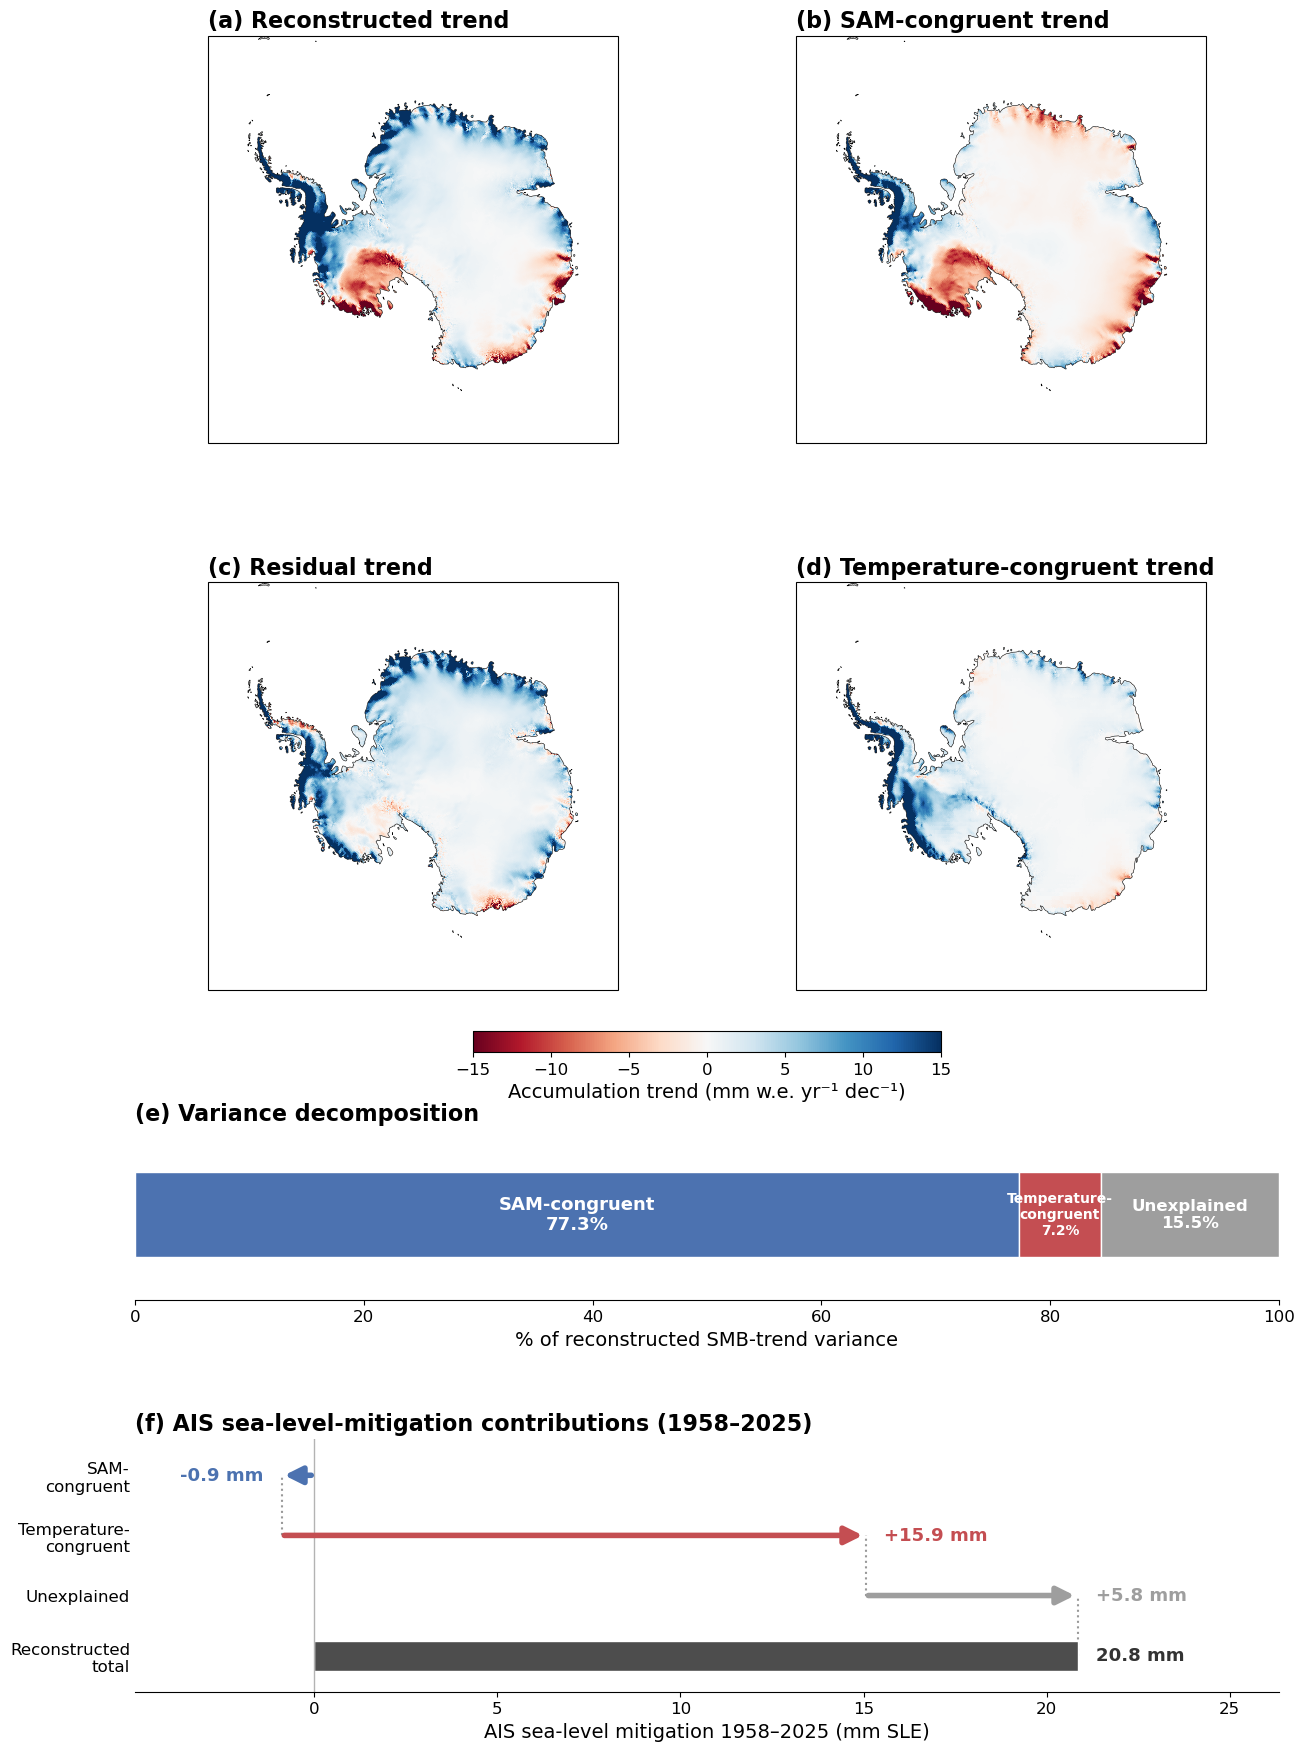

1958–2025:  SAM r²=77.3%   T(resid) r²=31.6%   → SAM 77.3% | T 7.2% | unexplained 15.5%
(f) AIS mitigation 1958–2025 = 20.8 mm  =  SAM -0.9 + Temperature +15.9 + Unexplained +5.8 mm


In [27]:
# ===== SAM decomposition + temperature-congruent trend + variance decomposition — recon+RACMO, 1958–2025 =====
import cartopy.crs as ccrs, cartopy.feature as cfeature
import matplotlib.gridspec as gridspec
GT = 361.8
def rc(a, b): m = np.isfinite(a) & np.isfinite(b); return np.corrcoef(a[m], b[m])[0, 1]

# joined per-cell SMB: reconstruction 1958–2000, raw RACMO 2001–2025
rec_part = racmo_smb_recon.reshape(200, -1)[1958-1801:2000-1801+1][:, valid_cells]      # 1958–2000
rac_part = smb_ann.sel(year=slice(2001, 2025)).values.reshape(-1, NY*NX)[:, valid_cells]  # 2001–2025
joined   = np.vstack([rec_part, rac_part])                                               # 1958–2025 (68 yr)
recon_tr = trend_cols(joined) * 10

sam_tr   = np.polyfit(np.arange(len(sam.loc[1958:2025])), sam.loc[1958:2025].values, 1)[0] * 10
samcong  = SAMsens_rate * sam_tr; resid = recon_tr - samcong
pred_brom = Tsens_rate * brom_trend(1958, 2025)[ii]
r_res, r_sam = rc(resid, pred_brom), rc(recon_tr, samcong)
r_sam2, r_res2 = 100*r_sam**2, 100*r_res**2

vlim = 15
panels = [("(a) Reconstructed trend", recon_tr), ("(b) SAM-congruent trend", samcong),
          ("(c) Residual trend", resid), ("(d) Temperature-congruent trend", pred_brom)]
fig = plt.figure(figsize=(13, 18))
gs = gridspec.GridSpec(4, 2, height_ratios=[1, 1, 0.42, 0.62], hspace=0.45, wspace=0.06,
                       left=0.06, right=0.94, top=0.97, bottom=0.05)
map_axes = []
for idx, (title, field) in enumerate(panels):
    ax = fig.add_subplot(gs[idx//2, idx % 2], projection=ccrs.SouthPolarStereo()); map_axes.append(ax)
    ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree()); ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
    im = ax.pcolormesh(lon_racmo, lat_racmo, paint_cells(field), transform=ccrs.PlateCarree(),
                       cmap="RdBu", vmin=-vlim, vmax=vlim, shading="nearest", zorder=1)
    ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=2); ax.add_feature(cfeature.COASTLINE, lw=0.4, zorder=3)
    ax.set_title(title, fontsize=16, fontweight="bold", loc="left")

# --- (e) single variance-decomposition bar (all shares of TOTAL, sum to 100%) ---
axe = fig.add_subplot(gs[2, :])
C_SAM, C_T, C_U = "#4C72B0", "#C44E52", "#9e9e9e"
S = r_sam2; Rr = 100 - S; T = r_res2/100 * Rr; U = Rr - T
axe.barh(0, S, left=0,   height=0.5, color=C_SAM, edgecolor="white")
axe.barh(0, T, left=S,   height=0.5, color=C_T,   edgecolor="white")
axe.barh(0, U, left=S+T, height=0.5, color=C_U,   edgecolor="white")
axe.text(S/2,     0, f"SAM-congruent\n{S:.1f}%",              ha="center", va="center", color="white", fontweight="bold", fontsize=13)
axe.text(S+T/2,   0, f"Temperature-\ncongruent\n{T:.1f}%",   ha="center", va="center", color="white", fontweight="bold", fontsize=10)
axe.text(S+T+U/2, 0, f"Unexplained\n{U:.1f}%",               ha="center", va="center", color="white", fontweight="bold", fontsize=12)
axe.set_xlim(0, 100); axe.set_ylim(-0.5, 0.5); axe.set_yticks([])
axe.set_xlabel("% of reconstructed SMB-trend variance", fontsize=14); axe.tick_params(axis="x", labelsize=12)
for sp in ("top", "right", "left"): axe.spines[sp].set_visible(False)
axe.set_title("(e) Variance decomposition", fontsize=16, fontweight="bold", loc="left")

# --- (f) AIS sea-level-mitigation contributions over the ATTRIBUTION window 1958–2025 ---
axf = fig.add_subplot(gs[3, :])
fmask = np.isfinite(recon_tr) & np.isfinite(samcong) & np.isfinite(pred_brom)
def _ig(fld): return (A_smb @ np.where(fmask, fld, 0.0))[0]                # AIS = region index 0
tot_tr = _ig(recon_tr)
f_S, f_T = _ig(samcong)/tot_tr, _ig(pred_brom)/tot_tr; f_U = 1 - f_S - f_T
comb = pd.concat([pd.Series(recon_series["AIS"], index=recon_years).loc[:1978], raw_series["AIS"].loc[1979:2025]])
mit  = pd.Series(np.cumsum(comb.loc[1901:2025].values - comb.loc[1801:1900].mean())/GT, index=np.arange(1901, 2026))
mit_tot = mit.loc[2025] - mit.loc[1957]                                    # mitigation accrued 1958–2025
cS, cT, cU = mit_tot*f_S, mit_tot*f_T, mit_tot*f_U

steps = [("SAM-\ncongruent", cS, C_SAM), ("Temperature-\ncongruent", cT, C_T), ("Unexplained", cU, C_U)]
ypos = [3, 2, 1]                                                            # rows, top → bottom
run = 0.0
for (lab, val, col), y in zip(steps, ypos):
    axf.annotate("", xy=(run+val, y), xytext=(run, y),
                 arrowprops=dict(arrowstyle="-|>", color=col, lw=4, mutation_scale=26))
    axf.plot([run+val, run+val], [y-1, y], ls=":", color="0.6", lw=1.5, zorder=0)       # connector to next row
    dx, ha = (0.5, "left") if val >= 0 else (-0.5, "right")
    axf.text(run+val+dx, y, f"{val:+.1f} mm", ha=ha, va="center", fontweight="bold", fontsize=13, color=col)
    run += val
axf.barh(0, mit_tot, height=0.5, color="0.3", edgecolor="white", zorder=1)              # accrued 1958–2025 total
axf.text(mit_tot+0.5, 0, f"{mit_tot:.1f} mm", ha="left", va="center", fontweight="bold", fontsize=13, color="0.2")
axf.axvline(0, color="0.7", lw=1)
xs = [0, cS, cS+cT, mit_tot]
axf.set_ylim(-0.6, 3.6); axf.set_xlim(min(xs)-4.0, max(xs)+5.5)
axf.set_yticks([3, 2, 1, 0]); axf.set_yticklabels([s[0] for s in steps] + ["Reconstructed\ntotal"], fontsize=12)
axf.set_xlabel("AIS sea-level mitigation 1958–2025 (mm SLE)", fontsize=14)
axf.tick_params(axis="x", labelsize=12); axf.tick_params(axis="y", length=0)
for sp in ("top", "right", "left"): axf.spines[sp].set_visible(False)
axf.set_title("(f) AIS sea-level-mitigation contributions (1958–2025)", fontsize=16, fontweight="bold", loc="left")

p2 = map_axes[2].get_position(); pe = axe.get_position(); gap = p2.y0 - pe.y1
cax = fig.add_axes([0.32, pe.y1 + 0.55*gap, 0.36, 0.012])
cb = fig.colorbar(im, cax=cax, orientation="horizontal")
cb.set_label("Accumulation trend (mm w.e. yr⁻¹ dec⁻¹)", fontsize=14); cb.ax.tick_params(labelsize=12)
plt.show()
print(f"1958–2025:  SAM r²={r_sam2:.1f}%   T(resid) r²={r_res2:.1f}%   "
      f"→ SAM {S:.1f}% | T {T:.1f}% | unexplained {U:.1f}%")
print(f"(f) AIS mitigation 1958–2025 = {mit_tot:.1f} mm  =  SAM {cS:+.1f} + Temperature {cT:+.1f} + Unexplained {cU:+.1f} mm")


## 9 · Mass balance vs ISMIP6 and GRACE

GRACE mascon load, the AIS three-panel comparison (SMB / total mass / inferred discharge) with a **grounded-consistent GRACE mask** and 2016-referenced ISMIP6, and the 2016–2050 ISMIP6 projection spread.

In [28]:
# ===== Load GRACE (JPL mascon RL06) → grace_annual + grace_masks =====
import os
grace = xr.open_dataset(os.path.expanduser("~/DataFiles/GRCTellus.JPL.200204_202604.GLO.RL06.3M.MSCNv04CRI.nc"))
gsub = grace["lwe_thickness"].sel(lat=slice(-90, -60))
glat = gsub["lat"].values; glon = gsub["lon"].values; ewh = gsub.values
Rm = 6371000.0
gcell = (Rm*Rm*np.deg2rad(0.5)*(np.sin(np.deg2rad(glat+0.25))-np.sin(np.deg2rad(glat-0.25))))[:, None]*np.ones((1, len(glon)))
glon2d, glat2d = np.meshgrid(glon, glat)
gidf = basin_mask[grounded_mask]                                       # basin id at each grounded cell
d, ii_g = cKDTree(to_xyz(lat_racmo[grounded_mask], lon_racmo[grounded_mask])).query(
    to_xyz(glat2d.ravel(), glon2d.ravel()))
near_basin = np.where(d*6371.0 < 150, gidf[ii_g], 0).reshape(glat2d.shape)   # nearest basin within 150 km
grace_masks = {"AIS": near_basin > 0, "WAIS": np.isin(near_basin, [3,7,8,9,10]),
               "EAIS": np.isin(near_basin, [1,2,11,12,13,14,15,16,17,18]), "AP": np.isin(near_basin, [4,5,6])}
gyear = pd.DatetimeIndex(grace["time"].values).year
def grace_annual(mask):
    m = np.array([np.nansum(np.where(mask, ewh[t]*gcell*10/1e12, 0)) for t in range(ewh.shape[0])])
    return pd.Series(m, index=gyear).groupby(level=0).mean()            # Gt, annual mean of 3-monthly solutions
print("GRACE ready:", ewh.shape, "| cells/basin:", {r: int(grace_masks[r].sum()) for r in region_names})


GRACE ready: (256, 60, 720) | cells/basin: {'AIS': 29215, 'WAIS': 6456, 'EAIS': 21845, 'AP': 914}


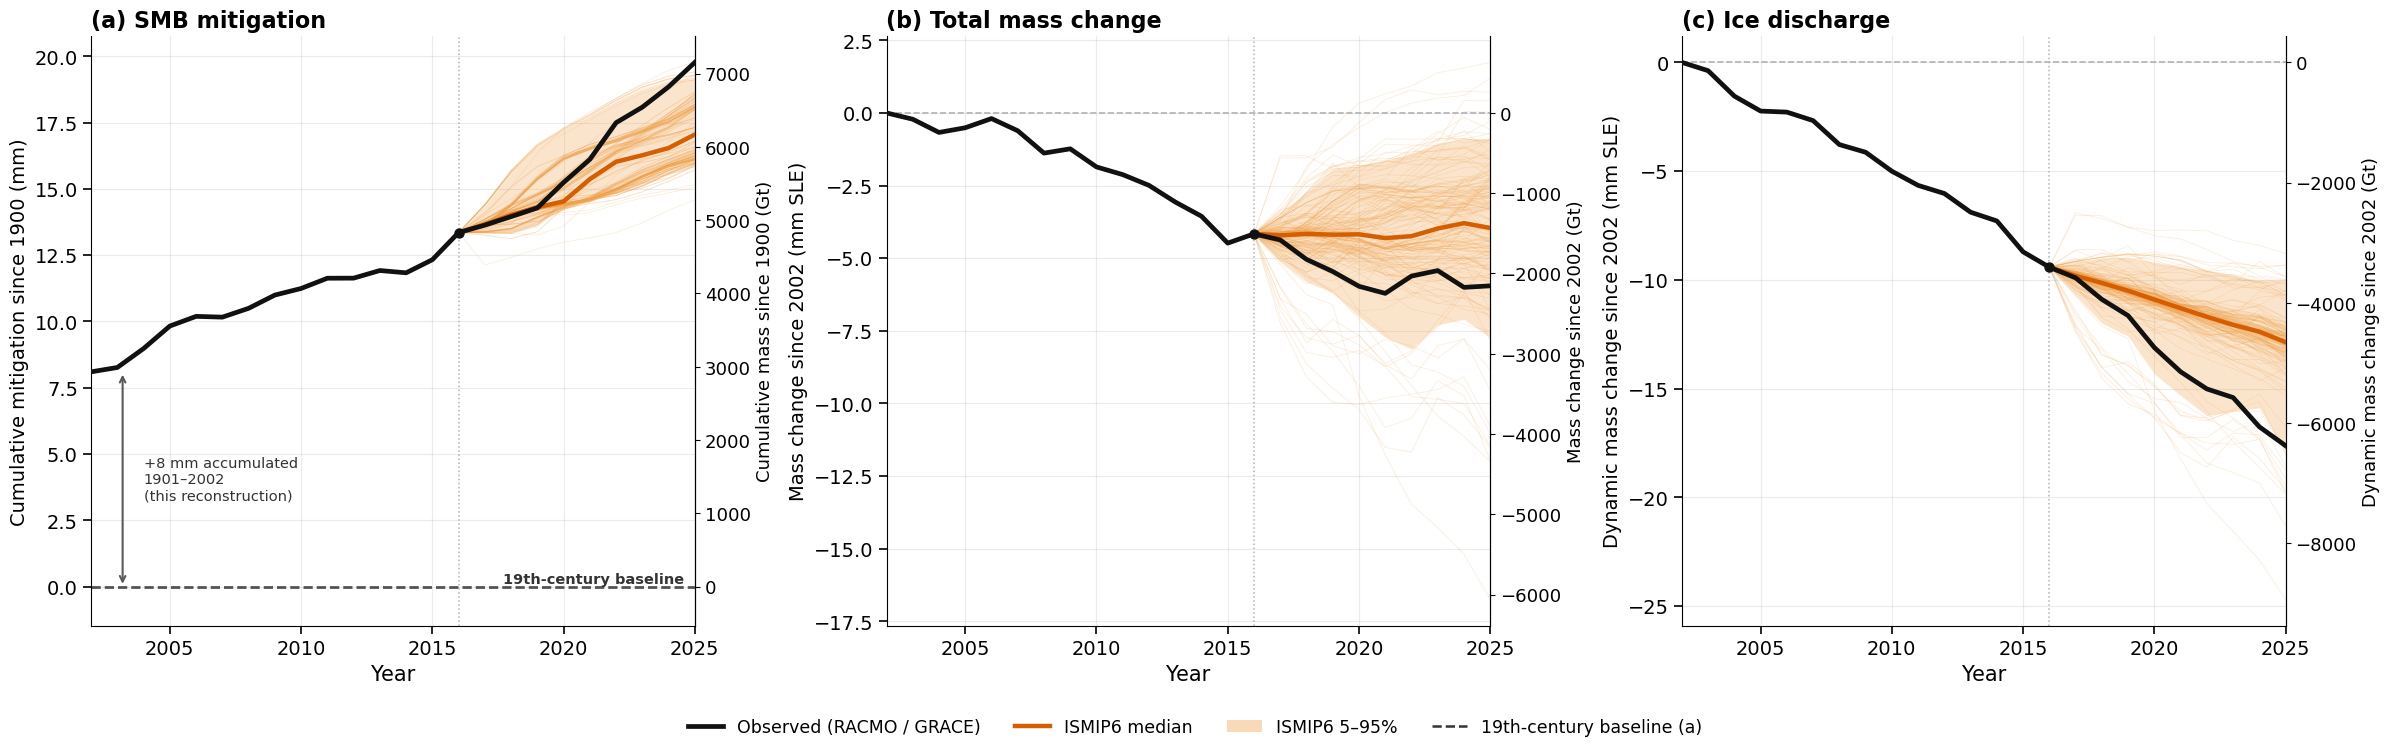

SMB   2016→2025:  obs +6.42 mm | ISMIP +3.70
TOTAL 2016→2025:  obs -1.79 mm | ISMIP +0.20 [-3.57,+3.27]
DISCH 2016→2025:  obs -8.21 mm | ISMIP -3.45 [-8.51,-0.66]


In [29]:
# ===== AIS: (a) SMB mitigation, (b) total mass change, (c) ice discharge — observations vs ISMIP6 =====
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
GT = 361.8; r = "AIS"
smb_np = np.load(os.path.expanduser("~/DataFiles/ISMIP6/ismip6_smb_traj.npz"), allow_pickle=True)
dyn_np = np.load(os.path.expanduser("~/DataFiles/ISMIP6/ismip6_dynAIS_traj.npz"), allow_pickle=True)
iyr = smb_np["years"]
i16, i25 = int(np.where(iyr == 2016)[0][0]), int(np.where(iyr == 2025)[0][0])
iyrs = iyr[i16:i25+1]
C_OBS, C_ISFAN, C_ISMED, C_BASE = "#111111", "#F0A24A", "#D55E00", "#333333"
def baseline_mean(r):
    return pd.concat([pd.Series(recon_series[r], index=recon_years).loc[:1978],
                      raw_series[r].loc[1979:]]).loc[1801:1900].mean()

# --- grounded-consistent GRACE mask: 150 km buffer, ice-shelf cells excluded ---
ice_sheet = xr.open_dataset(ant11_mask_file)["Icesheet_Only"].values == 1
floating  = ice_sheet & ~grounded_mask
gid_g  = basin_mask[grounded_mask]
tree_g = cKDTree(to_xyz(lat_racmo[grounded_mask], lon_racmo[grounded_mask]))
tree_f = cKDTree(to_xyz(lat_racmo[floating],      lon_racmo[floating]))
gpts   = to_xyz(glat2d.ravel(), glon2d.ravel())
dg, ig = tree_g.query(gpts); df, _ = tree_f.query(gpts); dg_km, df_km = dg*6371.0, df*6371.0
grace_mask_r = np.where((dg_km < 150) & (dg_km <= df_km), gid_g[ig], 0).reshape(glat2d.shape) > 0
def gann(mask):
    m = np.array([np.nansum(np.where(mask, ewh[t]*gcell*10/1e12, 0)) for t in range(ewh.shape[0])])
    return pd.Series(m, index=gyear).groupby(level=0).mean()

fig, (axa, axb, axc) = plt.subplots(1, 3, figsize=(24, 7.5))

# ---- (a) cumulative SMB mitigation since 1900 (0 = 19th-century baseline) vs ISMIP SMB ----
B = baseline_mean(r)
delta = raw_series[r].loc[1995:2014].mean() - B
comb = pd.concat([pd.Series(recon_series[r], index=recon_years).loc[:1978], raw_series[r].loc[1979:]])
mit = pd.Series(np.cumsum(comb.loc[1901:2025].values - B) / GT, index=np.arange(1901, 2026))
obs_win = mit.loc[2002:2025]; obs_at16, m02 = mit.loc[2016], mit.loc[2002]
ramp = delta * (iyrs - 2016) / GT
ism_s = obs_at16 + (smb_np[r][:, i16:i25+1] / GT - smb_np[r][:, i16:i16+1] / GT) + ramp[None, :]
mS, loS, hiS = np.median(ism_s, 0), *np.percentile(ism_s, [5, 95], 0)
for m in range(ism_s.shape[0]): axa.plot(iyrs, ism_s[m], color=C_ISFAN, lw=0.5, alpha=0.22, zorder=2)
axa.fill_between(iyrs, loS, hiS, color=C_ISFAN, alpha=0.28, lw=0, zorder=2.5)
axa.plot(iyrs, mS, color=C_ISMED, lw=3.2, zorder=4)
axa.plot(obs_win.index.values, obs_win.values, color=C_OBS, lw=3.4, zorder=5)
axa.scatter([2016], [obs_at16], color=C_OBS, s=42, zorder=6)
axa.axhline(0, color=C_BASE, lw=1.8, ls="--", zorder=1)
axa.annotate("", xy=(2003.2, m02), xytext=(2003.2, 0), arrowprops=dict(arrowstyle="<->", color="0.35", lw=1.5))
axa.text(2004, m02/2, f"+{m02:.0f} mm accumulated\n1901–2002\n(this reconstruction)",
         fontsize=10.5, va="center", ha="left", color="0.2")
axa.text(2024.6, 0, "19th-century baseline", color=C_BASE, fontsize=10.5, va="bottom", ha="right", fontweight="bold")
axa.set_ylim(bottom=min(-1.5, -0.06*mit.loc[2025]))
axa.set_title("(a) SMB mitigation", fontsize=16, fontweight="bold", loc="left")
axa.set_ylabel("Cumulative mitigation since 1900 (mm)", fontsize=14)

# ---- (b) total mass change: GRACE vs ISMIP total (SMB + dynamics), branch at 2016 (no ramp) ----
g = gann(grace_mask_r)
gser = (g.loc[2002:2025] - g.loc[2002]) / GT; g_at16 = gser.loc[2016]
tot = (smb_np[r] + dyn_np[r])[:, i16:i25+1] / GT
ism_t = g_at16 + (tot - tot[:, [0]])
mT, loT, hiT = np.median(ism_t, 0), *np.percentile(ism_t, [5, 95], 0)
for m in range(ism_t.shape[0]): axb.plot(iyrs, ism_t[m], color=C_ISFAN, lw=0.5, alpha=0.22, zorder=2)
axb.fill_between(iyrs, loT, hiT, color=C_ISFAN, alpha=0.28, lw=0, zorder=2.5)
axb.plot(iyrs, mT, color=C_ISMED, lw=3.2, zorder=4)
axb.plot(gser.index.values, gser.values, color=C_OBS, lw=3.4, zorder=5)
axb.scatter([2016], [g_at16], color=C_OBS, s=42, zorder=6)
axb.axhline(0, color="0.7", lw=1.2, ls="--", zorder=1)
axb.set_title("(b) Total mass change", fontsize=16, fontweight="bold", loc="left")
axb.set_ylabel("Mass change since 2002 (mm SLE)", fontsize=14)

# ---- (c) ice discharge: GRACE − preindustrial-referenced SMB vs ISMIP dynamics ----
smb_since02 = mit.loc[2002:2025] - m02
dyn_obs = gser - smb_since02.reindex(gser.index)
d_at16 = dyn_obs.loc[2016]
dcube = dyn_np[r][:, i16:i25+1] / GT
ism_d = d_at16 + (dcube - dcube[:, [0]]) - ramp[None, :]
mD, loD, hiD = np.median(ism_d, 0), *np.percentile(ism_d, [5, 95], 0)
for m in range(ism_d.shape[0]): axc.plot(iyrs, ism_d[m], color=C_ISFAN, lw=0.5, alpha=0.22, zorder=2)
axc.fill_between(iyrs, loD, hiD, color=C_ISFAN, alpha=0.28, lw=0, zorder=2.5)
axc.plot(iyrs, mD, color=C_ISMED, lw=3.2, zorder=4)
axc.plot(dyn_obs.index.values, dyn_obs.values, color=C_OBS, lw=3.4, zorder=5)
axc.scatter([2016], [d_at16], color=C_OBS, s=42, zorder=6)
axc.axhline(0, color="0.7", lw=1.2, ls="--", zorder=1)
axc.set_title("(c) Ice discharge", fontsize=16, fontweight="bold", loc="left")
axc.set_ylabel("Dynamic mass change since 2002 (mm SLE)", fontsize=14)

gt_labels = ["Cumulative mass since 1900 (Gt)", "Mass change since 2002 (Gt)", "Dynamic mass change since 2002 (Gt)"]
for ax, glab in zip((axa, axb, axc), gt_labels):
    ax.axvline(2016, color="0.7", lw=1.1, ls=":", zorder=1)
    ax.set_xlim(2002, 2025); ax.set_xlabel("Year", fontsize=15)
    ax.tick_params(labelsize=14, length=6, width=1.2); ax.grid(alpha=0.25)
    for sp in ("top",): ax.spines[sp].set_visible(False)
    secax = ax.secondary_yaxis("right", functions=(lambda y: y*GT, lambda y: y/GT))   # mm ↔ Gt
    secax.set_ylabel(glab, fontsize=13); secax.tick_params(labelsize=13)

handles = [Line2D([0],[0], color=C_OBS, lw=3.4, label="Observed (RACMO / GRACE)"),
           Line2D([0],[0], color=C_ISMED, lw=3.2, label="ISMIP6 median"),
           Patch(facecolor=C_ISFAN, alpha=0.4, label="ISMIP6 5–95%"),
           Line2D([0],[0], color=C_BASE, lw=1.8, ls="--", label="19th-century baseline (a)")]
fig.legend(handles=handles, loc="lower center", ncol=4, frameon=False, fontsize=12.5, bbox_to_anchor=(0.5, -0.03))
fig.tight_layout(rect=[0, 0.04, 1, 0.98]); plt.show()
print(f"SMB   2016→2025:  obs {mit.loc[2025]-obs_at16:+.2f} mm | ISMIP {mS[-1]-obs_at16:+.2f}")
print(f"TOTAL 2016→2025:  obs {gser.loc[2025]-gser.loc[2016]:+.2f} mm | ISMIP {mT[-1]-g_at16:+.2f} [{loT[-1]-g_at16:+.2f},{hiT[-1]-g_at16:+.2f}]")
print(f"DISCH 2016→2025:  obs {dyn_obs.loc[2025]-dyn_obs.loc[2016]:+.2f} mm | ISMIP {mD[-1]-d_at16:+.2f} [{loD[-1]-d_at16:+.2f},{hiD[-1]-d_at16:+.2f}]")



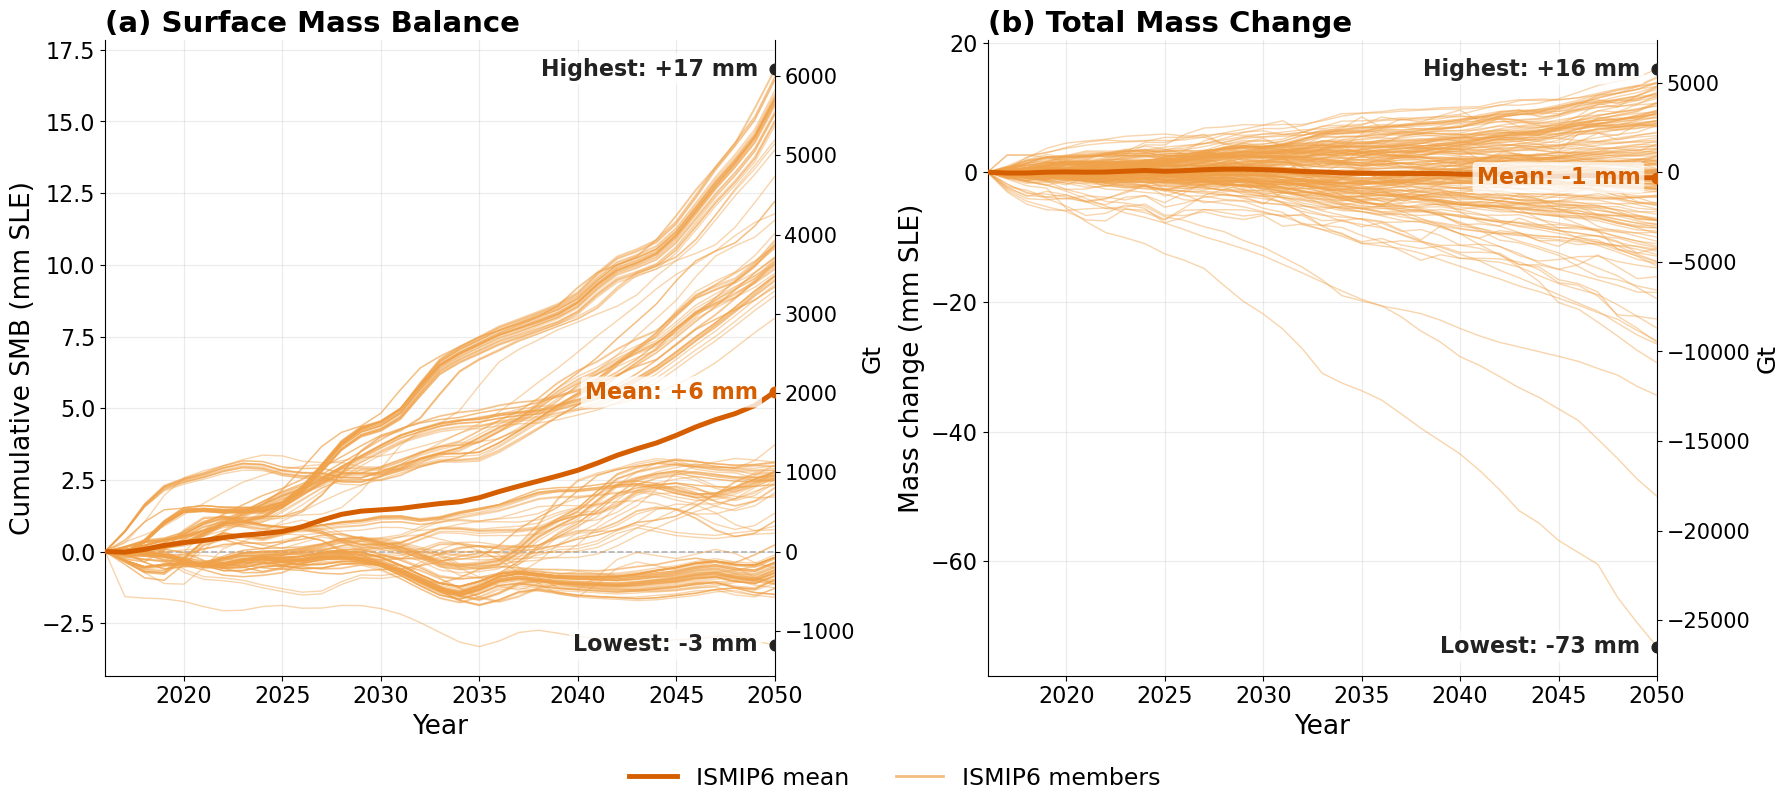

In [30]:
# ===== ISMIP6 AIS projection spread: SMB & total mass change, 2016–2050 (no observations) =====
GT = 361.8; r = "AIS"
smb_np = np.load(os.path.expanduser("~/DataFiles/ISMIP6/ismip6_smb_traj.npz"), allow_pickle=True)
dyn_np = np.load(os.path.expanduser("~/DataFiles/ISMIP6/ismip6_dynAIS_traj.npz"), allow_pickle=True)
iyr = smb_np["years"]; i0 = int(np.where(iyr == 2016)[0][0]); sel = iyr <= 2050; yrs = iyr[sel]
C_ISFAN, C_ISMED = "#F0A24A", "#D55E00"

smb_cum = (smb_np[r][:, sel] - smb_np[r][:, [i0]]) / GT                       # mm SLE, per member, ref 2016
tot_cum = ((smb_np[r]+dyn_np[r])[:, sel] - (smb_np[r]+dyn_np[r])[:, [i0]]) / GT

fig, (axa, axb) = plt.subplots(1, 2, figsize=(18, 8))
panels = [(axa, "(a) Surface Mass Balance", smb_cum, "Cumulative SMB (mm SLE)"),
          (axb, "(b) Total Mass Change",   tot_cum, "Mass change (mm SLE)")]
for ax, title, dat, ylab in panels:
    for mm in range(dat.shape[0]): ax.plot(yrs, dat[mm], color=C_ISFAN, lw=1.0, alpha=0.45, zorder=2)
    ax.plot(yrs, dat.mean(0), color=C_ISMED, lw=3.6, zorder=4)                # ensemble mean
    ax.axhline(0, color="0.7", lw=1.2, ls="--", zorder=1)
    v = dat[:, -1]                                                            # 2050 values across members
    for name, val, c in [("Highest", v.max(), "#222222"), ("Mean", v.mean(), C_ISMED), ("Lowest", v.min(), "#222222")]:
        ax.scatter([2050], [val], color=c, s=60, zorder=6)
        ax.annotate(f"{name}: {val:+.0f} mm", xy=(2050, val), xytext=(-12, 0), textcoords="offset points",
                    ha="right", va="center", fontsize=16, fontweight="bold", color=c,
                    bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="none", alpha=0.78), zorder=7)
    ax.set_title(title, fontsize=21, fontweight="bold", loc="left")
    ax.set_ylabel(ylab, fontsize=19); ax.set_xlabel("Year", fontsize=19)
    ax.set_xlim(2016, 2050); ax.tick_params(labelsize=16); ax.grid(alpha=0.25)
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)
    secax = ax.secondary_yaxis("right", functions=(lambda y: y*GT, lambda y: y/GT))
    secax.set_ylabel("Gt", fontsize=18); secax.tick_params(labelsize=15)

from matplotlib.lines import Line2D
fig.legend(handles=[Line2D([0],[0], color=C_ISMED, lw=3.5, label="ISMIP6 mean"),
                    Line2D([0],[0], color=C_ISFAN, lw=2.0, alpha=0.7, label="ISMIP6 members")],
           loc="lower center", ncol=2, frameon=False, fontsize=17, bbox_to_anchor=(0.5, -0.02))
fig.tight_layout(rect=[0, 0.05, 1, 1]); plt.show()


## 10 · Summary diagnostics

Mitigation uncertainty at 2000 and 2025, and the four-baseline mean-SMB table.

In [31]:
# ===== AIS sea-level-mitigation uncertainty at 2000 and 2025 (posterior-ensemble spread) =====
GT = 361.8; k = 0                                            # AIS = region index 0
def sea_level_mitigation(ts, b=slice(0,100)):
    ts = np.asarray(ts, float); return np.cumsum(ts - ts[b].mean())/GT
def extend_slm(recon_ts, obs_ts, b=slice(0,100)):
    r = np.asarray(recon_ts, float); base = r[b].mean(); return np.sum(r[:178]-base)/GT + np.cumsum((np.asarray(obs_ts)-base)/GT)

obs_ts = raw_series["AIS"].loc[1979:2025].values
M = smb_reg_ens.shape[1]
mit2000 = np.array([sea_level_mitigation(smb_reg_ens[:, m, k])[199] for m in range(M)])      # 2000 (reconstruction)
mit2025 = np.array([extend_slm(smb_reg_ens[:, m, k], obs_ts)[-1] for m in range(M)])          # 2025 (recon 1901–78 + RACMO)

for yr, arr in [(2000, mit2000), (2025, mit2025)]:
    mu, sd = arr.mean(), arr.std(ddof=1); lo, hi = np.percentile(arr, [2.5, 97.5])
    print(f"AIS mitigation {yr}:  {mu:6.2f} mm  |  ±{sd:.2f} (1σ)  |  95% CI [{lo:.2f}, {hi:.2f}]  |  ±{1.96*sd:.2f} (95%)")
    print(f"{'':17}  {mu*GT:6.0f} Gt  |  ±{sd*GT:.0f} (1σ)  |  95% CI [{lo*GT:.0f}, {hi*GT:.0f}]  |  ±{1.96*sd*GT:.0f} Gt (95%)")


AIS mitigation 2000:    7.51 mm  |  ±4.30 (1σ)  |  95% CI [-0.14, 16.40]  |  ±8.43 (95%)
                     2719 Gt  |  ±1557 (1σ)  |  95% CI [-51, 5932]  |  ±3051 Gt (95%)
AIS mitigation 2025:   19.77 mm  |  ±11.00 (1σ)  |  95% CI [4.44, 42.80]  |  ±21.56 (95%)
                     7152 Gt  |  ±3980 (1σ)  |  95% CI [1605, 15487]  |  ±7800 Gt (95%)


In [32]:
# ===== Print baseline mean SMB (± 2σ) for the four-baseline boxplot figure =====
def region_vals(r, y0, y1, src):
    s = pd.Series(recon_series[r], index=recon_years) if src == "recon" else raw_series[r]
    return s.loc[y0:y1].values

periods4 = [("1801–1900", 1801, 1900, "recon"), ("1979–2008", 1979, 2008, "raw"),
            ("1995–2010", 1995, 2010, "raw"), ("2002–2025", 2002, 2025, "raw")]

print(f"{'region':<6}" + "".join(f"{p[0]:>22}" for p in periods4) + "     (Gt/yr, mean ± 2σ)")
for r in region_names:
    row = f"{r:<6}"
    for (_, y0, y1, src) in periods4:
        v = region_vals(r, y0, y1, src)
        row += f"{v.mean():>12.1f} ± {2*v.std(ddof=1):>6.1f}"
    print(row)


region             1801–1900             1979–2008             1995–2010             2002–2025     (Gt/yr, mean ± 2σ)
AIS         1965.1 ±  219.7      2111.7 ±  220.8      2107.8 ±  181.3      2149.2 ±  265.0
WAIS         670.5 ±  178.2       712.0 ±  135.3       691.1 ±  144.5       707.3 ±  168.0
EAIS        1024.7 ±  186.6      1079.9 ±  171.8      1087.3 ±  189.4      1109.5 ±  189.3
AP           269.9 ±   90.1       319.8 ±   91.5       329.3 ±   97.2       332.4 ±  107.0
